# tRNA Optimization Results Analysis

This notebook aggregates and visualizes results from the tRNA optimization experiments.

## Overview

The tRNA optimization workflow trained 4 model variants for 190 pairwise amino acid comparisons:

1. **base**: ConvLSTMBase (signal + sequence only, no features)
2. **dwell**: ConvLSTMDwell (full model with all 3 branches)
3. **tcn_signal_features**: TCNSignalFeatures (signal + features only, optimized for constant sequence)
4. **dwell_masked**: ConvLSTMDwell with 50% sequence masking

**Goal**: Determine which architecture performs best for constant-sequence tRNA aminoacylation classification.

**Data Location**: `/home/jhesselberth@xsede.org/scratch/leech/synthetic-trna-opt/metrics/tRNA_optimization/pairwise/`

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from plotnine import *

warnings.filterwarnings('ignore')

# Set plotnine theme
theme_set(theme_minimal() + theme(figure_size=(12, 6)))

## 1. Data Loading

Load comparison results from all 190 pairwise comparisons.

In [3]:
# Base directory containing results
BASE_DIR = Path("/home/jhesselberth@xsede.org/scratch/leech/synthetic-trna-opt/metrics/tRNA_optimization/pairwise")

# Model variants
VARIANTS = ['base', 'dwell', 'tcn_signal_features', 'dwell_masked']
VARIANT_LABELS = {
    'base': 'ConvLSTMBase\n(no features)',
    'dwell': 'ConvLSTMDwell\n(full model)',
    'tcn_signal_features': 'TCNSignalFeatures\n(signal+features)',
    'dwell_masked': 'ConvLSTMDwell\n(masked)'
}

# Variants that have sequence branch (for ablation analysis)
VARIANTS_WITH_SEQUENCE = ['base', 'dwell', 'dwell_masked']
VARIANTS_WITHOUT_SEQUENCE = ['tcn_signal_features']  # Signal-only models

# Metrics to track
METRICS = ['accuracy', 'precision', 'recall', 'f1', 'auroc', 'auprc']

print(f"Base directory: {BASE_DIR}")
print(f"Directory exists: {BASE_DIR.exists()}")

Base directory: /home/jhesselberth@xsede.org/scratch/leech/synthetic-trna-opt/metrics/tRNA_optimization/pairwise
Directory exists: True


In [4]:
def load_all_comparison_results(base_dir):
    """
    Load comparison results from all pairwise directories.

    Returns:
        DataFrame with columns: pair, variant, accuracy, precision, recall, f1, auroc, auprc
    """
    results = []

    # Iterate through all pairwise comparison directories
    for pair_dir in sorted(base_dir.iterdir()):
        if not pair_dir.is_dir():
            continue

        pair_name = pair_dir.name
        comparison_file = pair_dir / "comparison_results.json"

        if not comparison_file.exists():
            print(f"Warning: Missing comparison_results.json for {pair_name}")
            continue

        # Load comparison results
        with open(comparison_file) as f:
            data = json.load(f)

        # Extract metrics for each variant
        for variant in VARIANTS:
            if variant not in data:
                print(f"Warning: Missing variant '{variant}' for {pair_name}")
                continue

            variant_data = data[variant]
            row = {
                'pair': pair_name,
                'variant': variant,
                'accuracy': variant_data.get('accuracy', np.nan),
                'precision': variant_data.get('precision', np.nan),
                'recall': variant_data.get('recall', np.nan),
                'f1': variant_data.get('f1', np.nan),
                'auroc': variant_data.get('auroc', np.nan),
                'auprc': variant_data.get('auprc', np.nan),
                'num_samples': variant_data.get('num_samples', np.nan)
            }
            results.append(row)

    df = pd.DataFrame(results)
    return df


# Load all results
print("Loading all comparison results...")
df_results = load_all_comparison_results(BASE_DIR)

print(f"\nLoaded {len(df_results)} variant results from {df_results['pair'].nunique()} pairwise comparisons")
print(f"\nVariants: {df_results['variant'].unique()}")
print("\nFirst few rows:")
df_results.head(10)

Loading all comparison results...

Loaded 760 variant results from 190 pairwise comparisons

Variants: ['base' 'dwell'
 'tcn_signal_features'
 'dwell_masked']

First few rows:


,pair,variant,accuracy,precision,recall,f1,auroc,auprc,num_samples
0,Ala_Arg,base,0.842857,0.866310,0.952941,0.907563,0.841618,0.945302,210
1,Ala_Arg,dwell,0.700000,0.868966,0.741176,0.800000,0.654559,0.866782,210
2,Ala_Arg,tcn_signal_features,0.661905,0.883721,0.670588,0.762542,0.697794,0.893428,210
3,Ala_Arg,dwell_masked,0.738095,0.861635,0.805882,0.832827,0.689706,0.897267,210
4,Ala_Asn,base,0.748691,0.900000,0.769737,0.829787,0.787449,0.920940,191
5,Ala_Asn,dwell,0.780105,0.802198,0.960526,0.874251,0.697031,0.903486,191
6,Ala_Asn,tcn_signal_features,0.575916,0.814159,0.605263,0.694340,0.547402,0.839723,191
7,Ala_Asn,dwell_masked,0.706806,0.828767,0.796053,0.812081,0.623650,0.852732,191
8,Ala_Asp,base,0.954264,0.993421,0.959492,0.976162,0.882600,0.995545,1290
9,Ala_Asp,dwell,0.956589,0.991823,0.963463,0.977438,0.886392,0.995930,1290


## 2. Data Quality Check

Check for missing data and ensure all variants have results for all pairs.

In [5]:
# Check for missing values
print("Missing values per metric:")
print(df_results[METRICS].isnull().sum())
print()

# Check completeness by variant
print("Results per variant:")
print(df_results.groupby('variant').size())
print()

# Check if any pairs are missing variants
pair_variant_counts = df_results.groupby('pair')['variant'].nunique()
incomplete_pairs = pair_variant_counts[pair_variant_counts < 4]
if len(incomplete_pairs) > 0:
    print(f"Warning: {len(incomplete_pairs)} pairs have incomplete variant results:")
    print(incomplete_pairs)
else:
    print("All pairs have results for all 4 variants!")

Missing values per metric:
accuracy     0
precision    0
recall       0
f1           0
auroc        0
auprc        0
dtype: int64

Results per variant:
variant
base                   190
dwell                  190
dwell_masked           190
tcn_signal_features    190
dtype: int64

All pairs have results for all 4 variants!


## 3. Overall Performance Summary

Aggregate metrics across all pairwise comparisons to determine the best variant.

In [6]:
# Compute mean and std for each variant across all pairs
summary_stats = df_results.groupby('variant')[METRICS].agg(['mean', 'std'])
summary_stats = summary_stats.round(4)

print("Overall Performance (Mean ± Std across all 190 pairwise comparisons)")
print("="*80)
print(summary_stats)
print()

# Find best variant for each metric
print("Best variant per metric (by mean):")
print("="*80)
for metric in METRICS:
    best_variant = df_results.groupby('variant')[metric].mean().idxmax()
    best_value = df_results.groupby('variant')[metric].mean().max()
    print(f"{metric:12s}: {best_variant:25s} ({best_value:.4f})")

Overall Performance (Mean ± Std across all 190 pairwise comparisons)
                    accuracy  \
                        mean   
variant                        
base                  0.8609   
dwell                 0.8583   
dwell_masked          0.8526   
tcn_signal_features   0.6600   

                             \
                        std   
variant                       
base                 0.0806   
dwell                0.0866   
dwell_masked         0.0900   
tcn_signal_features  0.0742   

                    precision  \
                         mean   
variant                         
base                   0.8738   
dwell                  0.8679   
dwell_masked           0.8541   
tcn_signal_features    0.7296   

                             \
                        std   
variant                       
base                 0.1322   
dwell                0.1417   
dwell_masked         0.1553   
tcn_signal_features  0.2210   

                     recall  \
       

## 4. Visualizations

### 4.1 Overall Performance Comparison

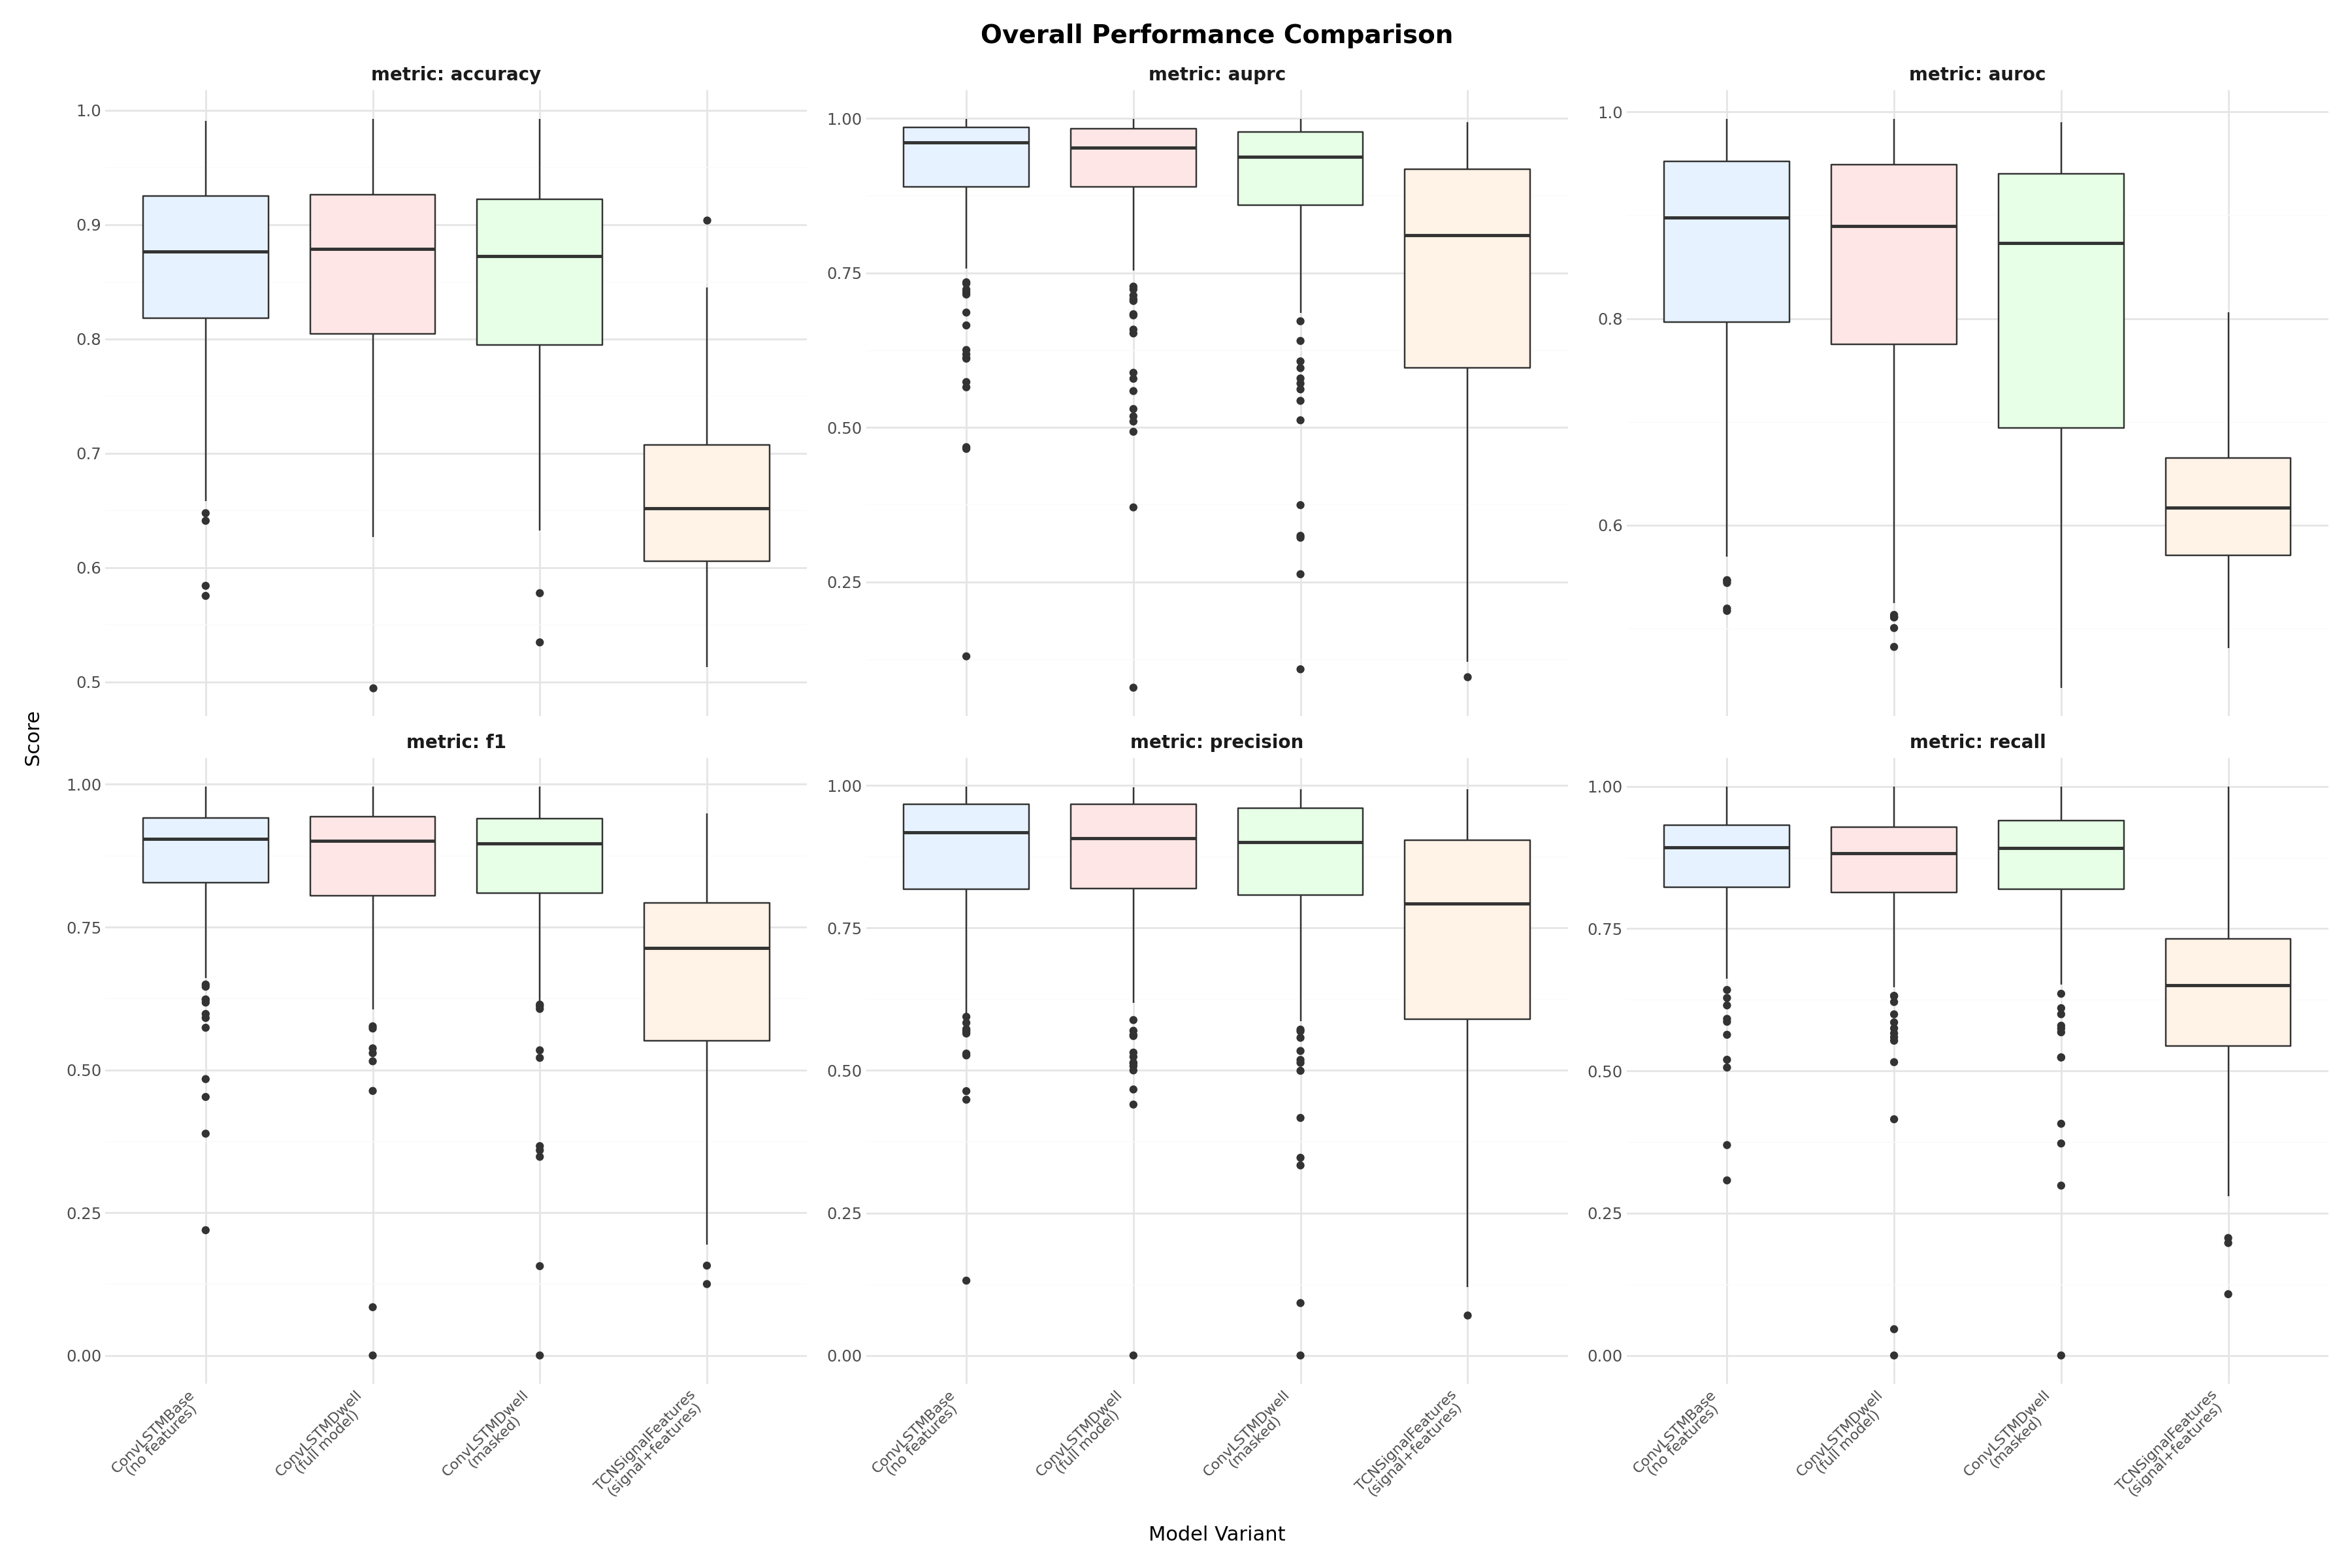

In [ ]:
# Create box plots for each metric
# Reshape data for plotnine
plot_data = df_results.melt(
    id_vars=['pair', 'variant'],
    value_vars=METRICS,
    var_name='metric',
    value_name='score'
)
plot_data['variant_label'] = plot_data['variant'].map(VARIANT_LABELS)

# Create faceted boxplot
(
    ggplot(plot_data, aes(x='variant_label', y='score', fill='variant'))
    + geom_boxplot(show_legend=False)
    + facet_wrap('~metric', scales='free_y', ncol=3, labeller='label_both')
    + scale_fill_manual(values=['#e6f2ff', '#ffe6e6', '#e6ffe6', '#fff2e6'])
    + labs(x='Model Variant', y='Score', title='Overall Performance Comparison')
    + theme_minimal()
    + theme(
        figure_size=(18, 12),
        axis_text_x=element_text(angle=45, hjust=1, size=8),
        strip_text=element_text(size=10, weight='bold'),
        plot_title=element_text(size=14, weight='bold')
    )
).show()

### 4.2 Pairwise Win Rate

For each pairwise comparison, which variant performed best?

Win counts (number of pairwise comparisons where each variant was best):
                     accuracy  \
base                      107   
dwell                      56   
tcn_signal_features         1   
dwell_masked               26   

                     precision  \
base                        88   
dwell                       66   
tcn_signal_features          9   
dwell_masked                27   

                     recall   f1  \
base                     74  102   
dwell                    60   59   
tcn_signal_features       4    0   
dwell_masked             52   29   

                     auroc  auprc  
base                   121    117  
dwell                   48     48  
tcn_signal_features      2      2  
dwell_masked            19     23  



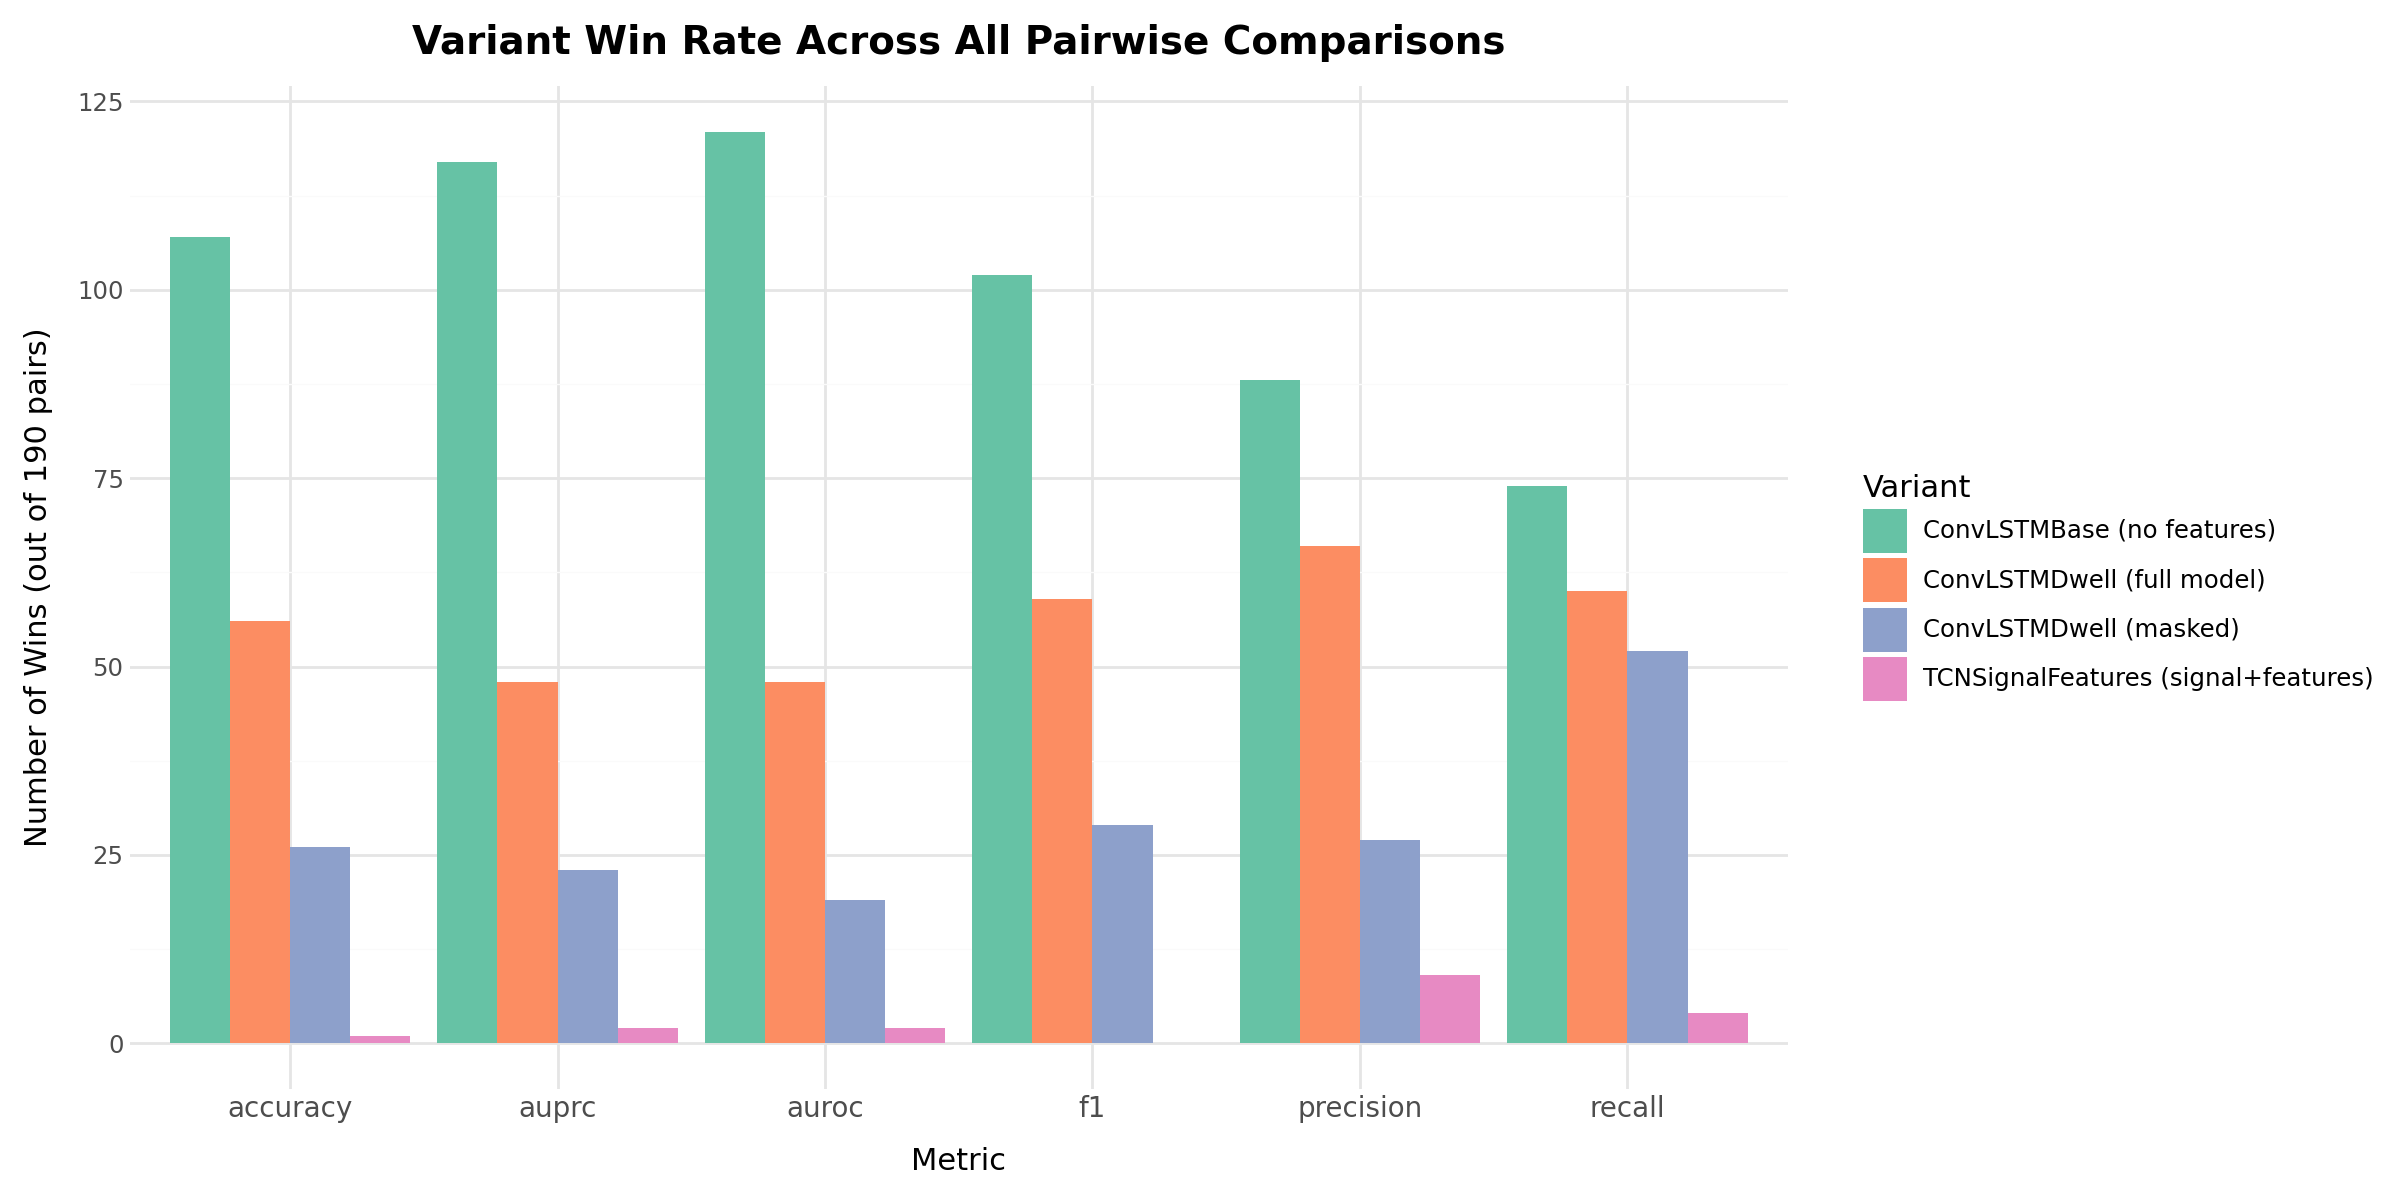

In [ ]:
def count_wins(df, metric='accuracy'):
    """
    Count how many times each variant was the best for each pair.
    """
    wins = dict.fromkeys(VARIANTS, 0)

    for pair in df['pair'].unique():
        pair_data = df[df['pair'] == pair]
        best_variant = pair_data.loc[pair_data[metric].idxmax(), 'variant']
        wins[best_variant] += 1

    return wins


# Count wins for each metric
win_counts = pd.DataFrame({metric: count_wins(df_results, metric)
                          for metric in METRICS})

print("Win counts (number of pairwise comparisons where each variant was best):")
print("="*80)
print(win_counts)
print()

# Reshape for plotnine
win_data = win_counts.reset_index().melt(
    id_vars='index',
    var_name='metric',
    value_name='wins'
)
win_data = win_data.rename(columns={'index': 'variant'})
win_data['variant_label'] = win_data['variant'].map(
    lambda x: VARIANT_LABELS[x].replace('\n', ' ')
)

# Create grouped bar chart
(
    ggplot(win_data, aes(x='metric', y='wins', fill='variant_label'))
    + geom_bar(stat='identity', position='dodge')
    + scale_fill_brewer(type='qual', palette='Set2')
    + labs(
        x='Metric',
        y='Number of Wins (out of 190 pairs)',
        title='Variant Win Rate Across All Pairwise Comparisons',
        fill='Variant'
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 6),
        axis_text_x=element_text(size=10),
        legend_position='right',
        plot_title=element_text(size=14, weight='bold')
    )
).show()

### 4.3 Distribution Analysis

Violin plots showing the full distribution of performance across all pairs.

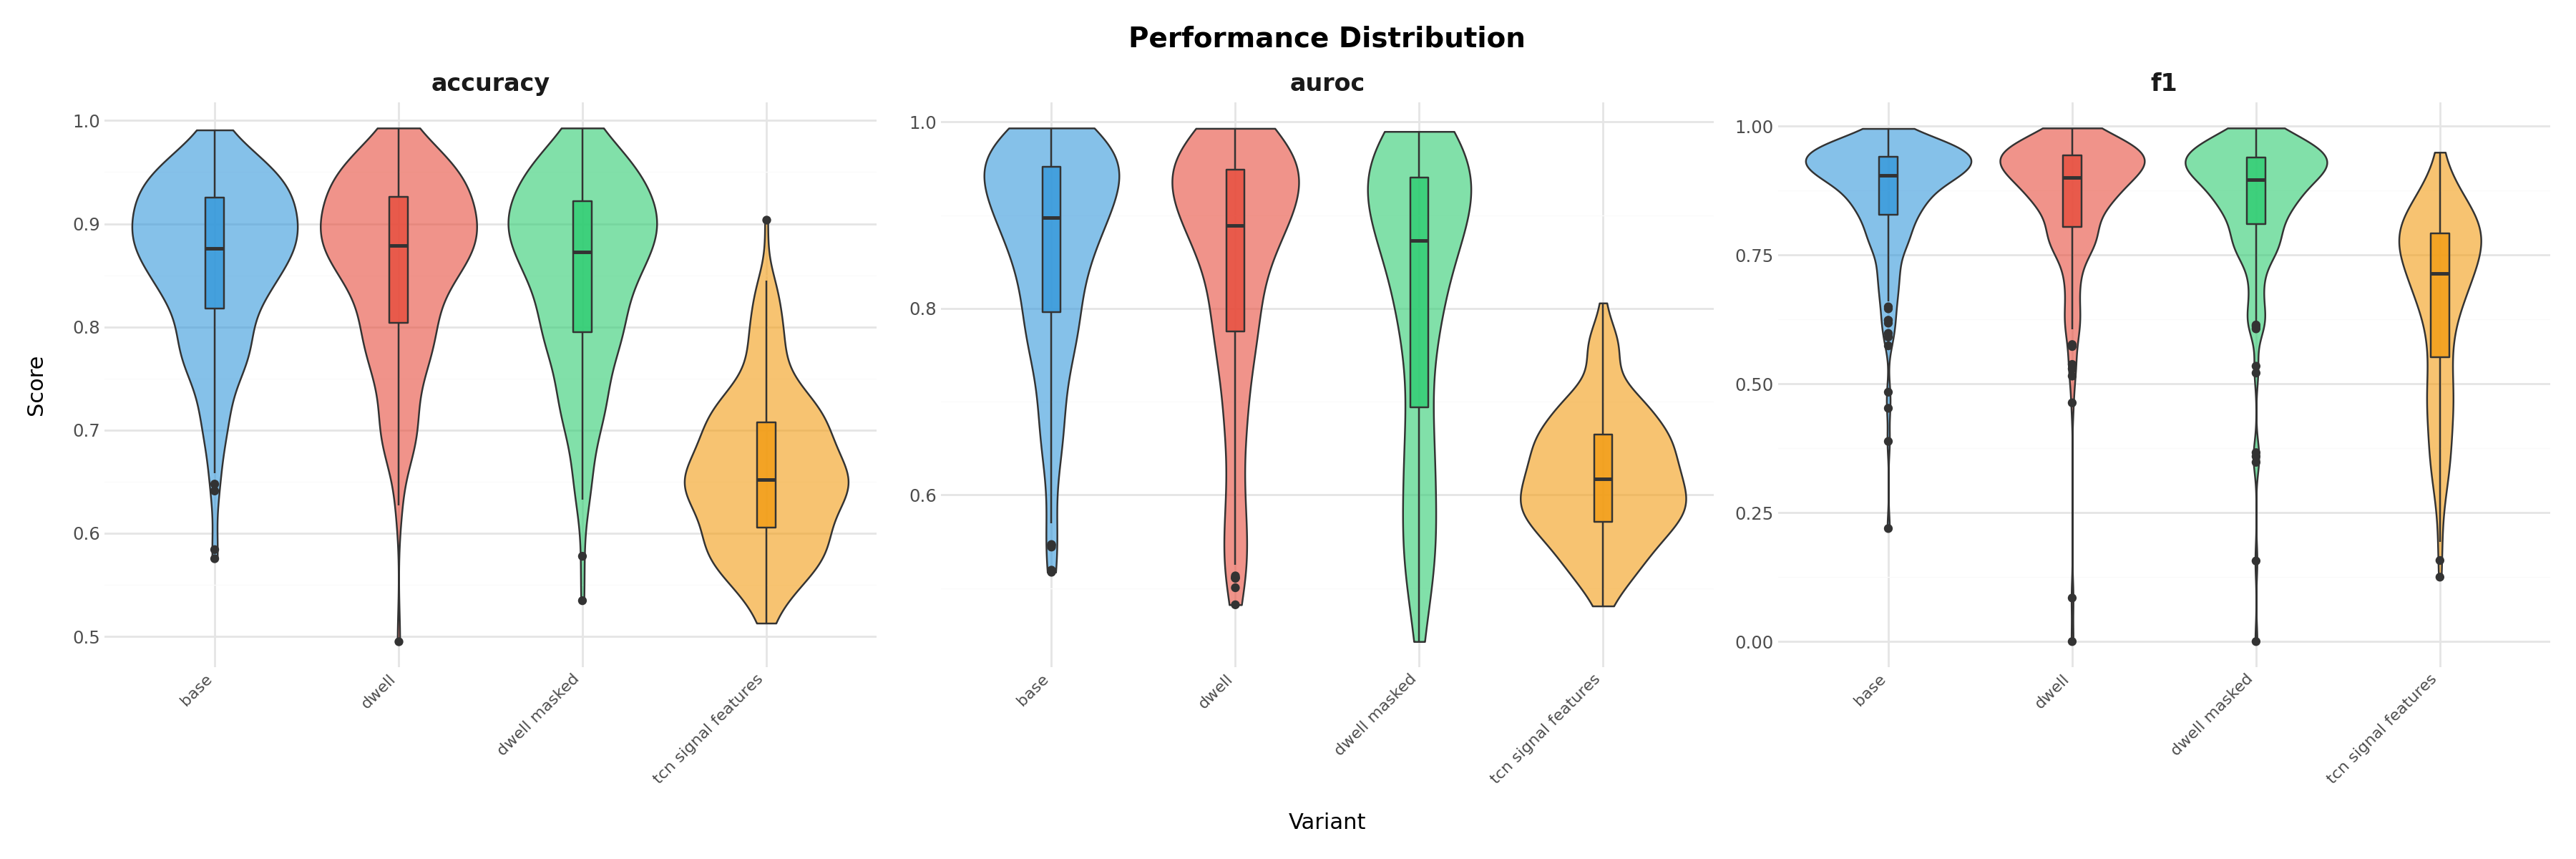

In [9]:
# Focus on key metrics
key_metrics = ['accuracy', 'f1', 'auroc']

# Filter data for key metrics
violin_data = df_results.melt(
    id_vars=['pair', 'variant'],
    value_vars=key_metrics,
    var_name='metric',
    value_name='score'
)
violin_data['variant_label'] = violin_data['variant'].map(
    lambda x: x.replace('_', ' ')
)

# Create violin plots
(
    ggplot(violin_data, aes(x='variant_label', y='score', fill='variant'))
    + geom_violin(alpha=0.6, show_legend=False)
    + geom_boxplot(width=0.1, alpha=0.8, show_legend=False)
    + facet_wrap('~metric', scales='free_y', ncol=3)
    + scale_fill_manual(values=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
    + labs(x='Variant', y='Score', title='Performance Distribution')
    + theme_minimal()
    + theme(
        figure_size=(18, 6),
        axis_text_x=element_text(angle=45, hjust=1, size=8),
        strip_text=element_text(size=12, weight='bold'),
        plot_title=element_text(size=14, weight='bold')
    )
).show()

### 4.4 Heatmap: Performance by Amino Acid Pair

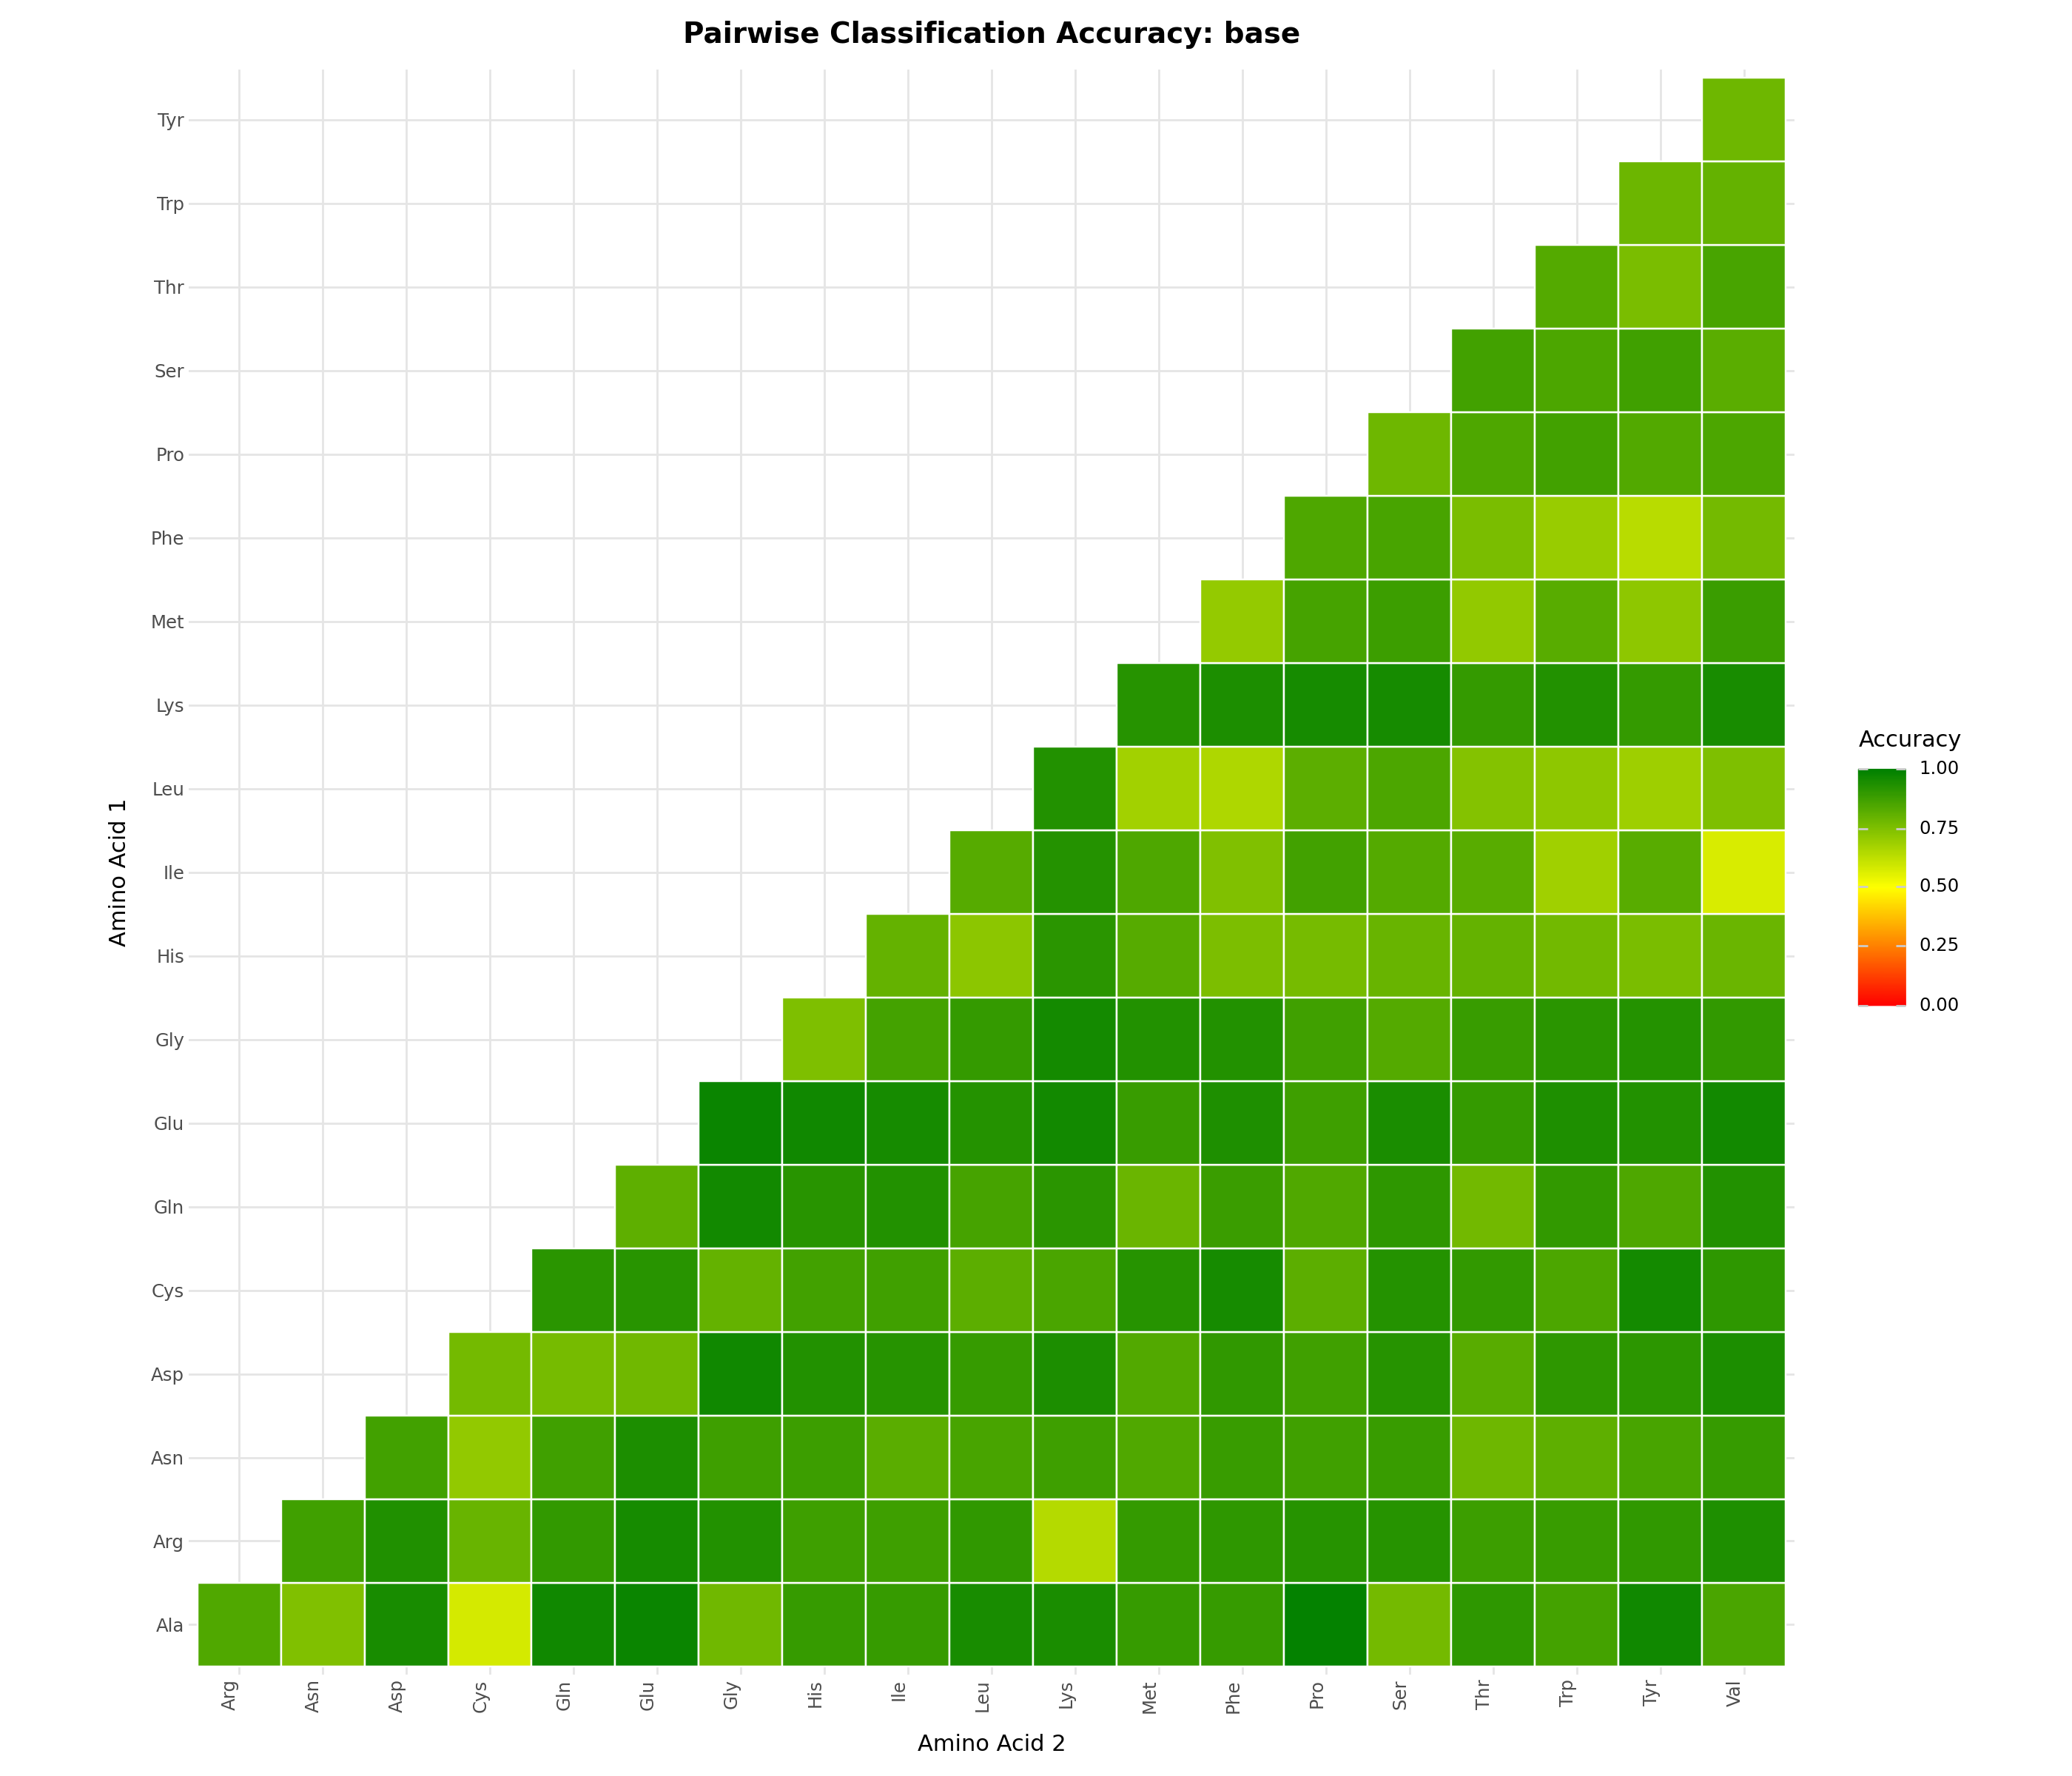

In [10]:
# Extract amino acids and create a dataframe for heatmap
best_variant = df_results.groupby('variant')['accuracy'].mean().idxmax()

# Prepare data for heatmap
heatmap_data = df_results[df_results['variant'] == best_variant].copy()
heatmap_data[['aa1', 'aa2']] = heatmap_data['pair'].str.split('_', expand=True)

# Create heatmap using geom_tile
(
    ggplot(heatmap_data, aes(x='aa2', y='aa1', fill='accuracy'))
    + geom_tile(color='white', size=0.5)
    + scale_fill_gradient2(
        low='red', mid='yellow', high='green',
        midpoint=0.5, limits=[0, 1],
        name='Accuracy'
    )
    + labs(
        x='Amino Acid 2',
        y='Amino Acid 1',
        title=f'Pairwise Classification Accuracy: {best_variant}'
    )
    + theme_minimal()
    + theme(
        figure_size=(14, 12),
        axis_text_x=element_text(angle=90, hjust=1),
        aspect_ratio=1,
        plot_title=element_text(size=14, weight='bold')
    )
    + coord_equal()
).show()

## 5. ⭐ SEQUENCE ABLATION ANALYSIS ⭐

**This is the KEY analysis** - Does removing/randomizing sequences affect model performance?

- **Models WITH sequence branch (base, dwell, dwell_masked)**: Should show LARGE performance drops if overfitting to constant sequence
- **Models WITHOUT sequence branch (tcn_signal_features)**: Should show NO performance drop (already ignores sequence)

This validates whether signal-only models truly solve the overfitting problem.

In [11]:
def load_sequence_ablation_results(base_dir):
    """
    Load sequence ablation results for models with sequence branches.

    Returns:
        DataFrame with columns: pair, variant, normal_acc, zeros_acc, random_acc,
                                zeros_drop_pct, random_drop_pct
    """
    results = []

    for pair_dir in sorted(base_dir.iterdir()):
        if not pair_dir.is_dir():
            continue

        pair_name = pair_dir.name
        ablation_file = pair_dir / "sequence_ablation" / "sequence_ablation.json"

        if not ablation_file.exists():
            continue

        # Load ablation results
        with open(ablation_file) as f:
            data = json.load(f)

        # The ablation was done on the 'dwell' variant (full model)
        row = {
            'pair': pair_name,
            'variant': 'dwell',  # Ablation is done on full model
            'normal_accuracy': data['normal'].get('accuracy', np.nan),
            'zeros_accuracy': data['zeros'].get('accuracy', np.nan),
            'random_accuracy': data['random'].get('accuracy', np.nan),
            'zeros_drop_pct': data['zeros_drop'].get('accuracy_drop_pct', np.nan),
            'random_drop_pct': data['random_drop'].get('accuracy_drop_pct', np.nan),
            'normal_f1': data['normal'].get('f1', np.nan),
            'zeros_f1': data['zeros'].get('f1', np.nan),
            'random_f1': data['random'].get('f1', np.nan),
            'zeros_f1_drop_pct': data['zeros_drop'].get('f1_drop_pct', np.nan),
            'random_f1_drop_pct': data['random_drop'].get('f1_drop_pct', np.nan)
        }
        results.append(row)

    return pd.DataFrame(results)


# Load ablation results
print("Loading sequence ablation results...")
df_ablation = load_sequence_ablation_results(BASE_DIR)

print(f"\nLoaded ablation results for {len(df_ablation)} pairwise comparisons")
print("\nFirst few rows:")
df_ablation.head()

Loading sequence ablation results...

Loaded ablation results for 190 pairwise comparisons

First few rows:


,pair,variant,normal_accuracy,zeros_accuracy,random_accuracy,zeros_drop_pct,random_drop_pct,normal_f1,zeros_f1,random_f1,zeros_f1_drop_pct,random_f1_drop_pct
0,Ala_Arg,dwell,0.700000,0.700000,0.700000,0.000000,0.000000,0.800000,0.800000,0.800000,0.000000,0.000000
1,Ala_Asn,dwell,0.780105,0.790576,0.774869,-1.342282,0.671141,0.874251,0.881657,0.870871,-0.847045,0.386688
2,Ala_Asp,dwell,0.956589,0.027907,0.724031,97.082658,24.311183,0.977438,0.007911,0.839495,99.190599,14.112667
3,Ala_Cys,dwell,0.495050,0.485149,0.485149,2.000000,2.000000,0.463158,0.434783,0.446809,6.126482,3.529981
4,Ala_Gln,dwell,0.931929,0.023501,0.731767,97.478261,21.478261,0.964225,0.003309,0.843794,99.656873,12.489890


In [12]:
# Analyze ablation results
print("\n" + "="*80)
print("SEQUENCE ABLATION SUMMARY (ConvLSTMDwell - Full Model)")
print("="*80)
print()
print("Mean performance across all 190 pairs:")
print(f"  Normal accuracy:         {df_ablation['normal_accuracy'].mean():.4f} ± {df_ablation['normal_accuracy'].std():.4f}")
print(f"  Zeros accuracy:          {df_ablation['zeros_accuracy'].mean():.4f} ± {df_ablation['zeros_accuracy'].std():.4f}")
print(f"  Random accuracy:         {df_ablation['random_accuracy'].mean():.4f} ± {df_ablation['random_accuracy'].std():.4f}")
print()
print("Mean performance drops:")
print(f"  Zeros drop (%):          {df_ablation['zeros_drop_pct'].mean():.2f}% ± {df_ablation['zeros_drop_pct'].std():.2f}%")
print(f"  Random drop (%):         {df_ablation['random_drop_pct'].mean():.2f}% ± {df_ablation['random_drop_pct'].std():.2f}%")
print()
print("Interpretation:")
if abs(df_ablation['zeros_drop_pct'].mean()) < 1.0:
    print("  ✓ Model does NOT rely on sequence (no drop when sequences ablated)")
    print("  → Signal-only approach is working!")
elif abs(df_ablation['zeros_drop_pct'].mean()) < 5.0:
    print("  ≈ Model MINIMALLY relies on sequence (small drop when sequences ablated)")
    print("  → Sequence masking may be helping")
else:
    print("  ✗ Model HEAVILY relies on sequence (large drop when sequences ablated)")
    print("  → This indicates sequence overfitting to constant CCAGGC motif")
print("="*80)


SEQUENCE ABLATION SUMMARY (ConvLSTMDwell - Full Model)

Mean performance across all 190 pairs:
  Normal accuracy:         0.8583 ± 0.0866
  Zeros accuracy:          0.5581 ± 0.2731
  Random accuracy:         0.5933 ± 0.1809

Mean performance drops:
  Zeros drop (%):          34.50% ± 31.10%
  Random drop (%):         30.72% ± 19.84%

Interpretation:
  ✗ Model HEAVILY relies on sequence (large drop when sequences ablated)
  → This indicates sequence overfitting to constant CCAGGC motif


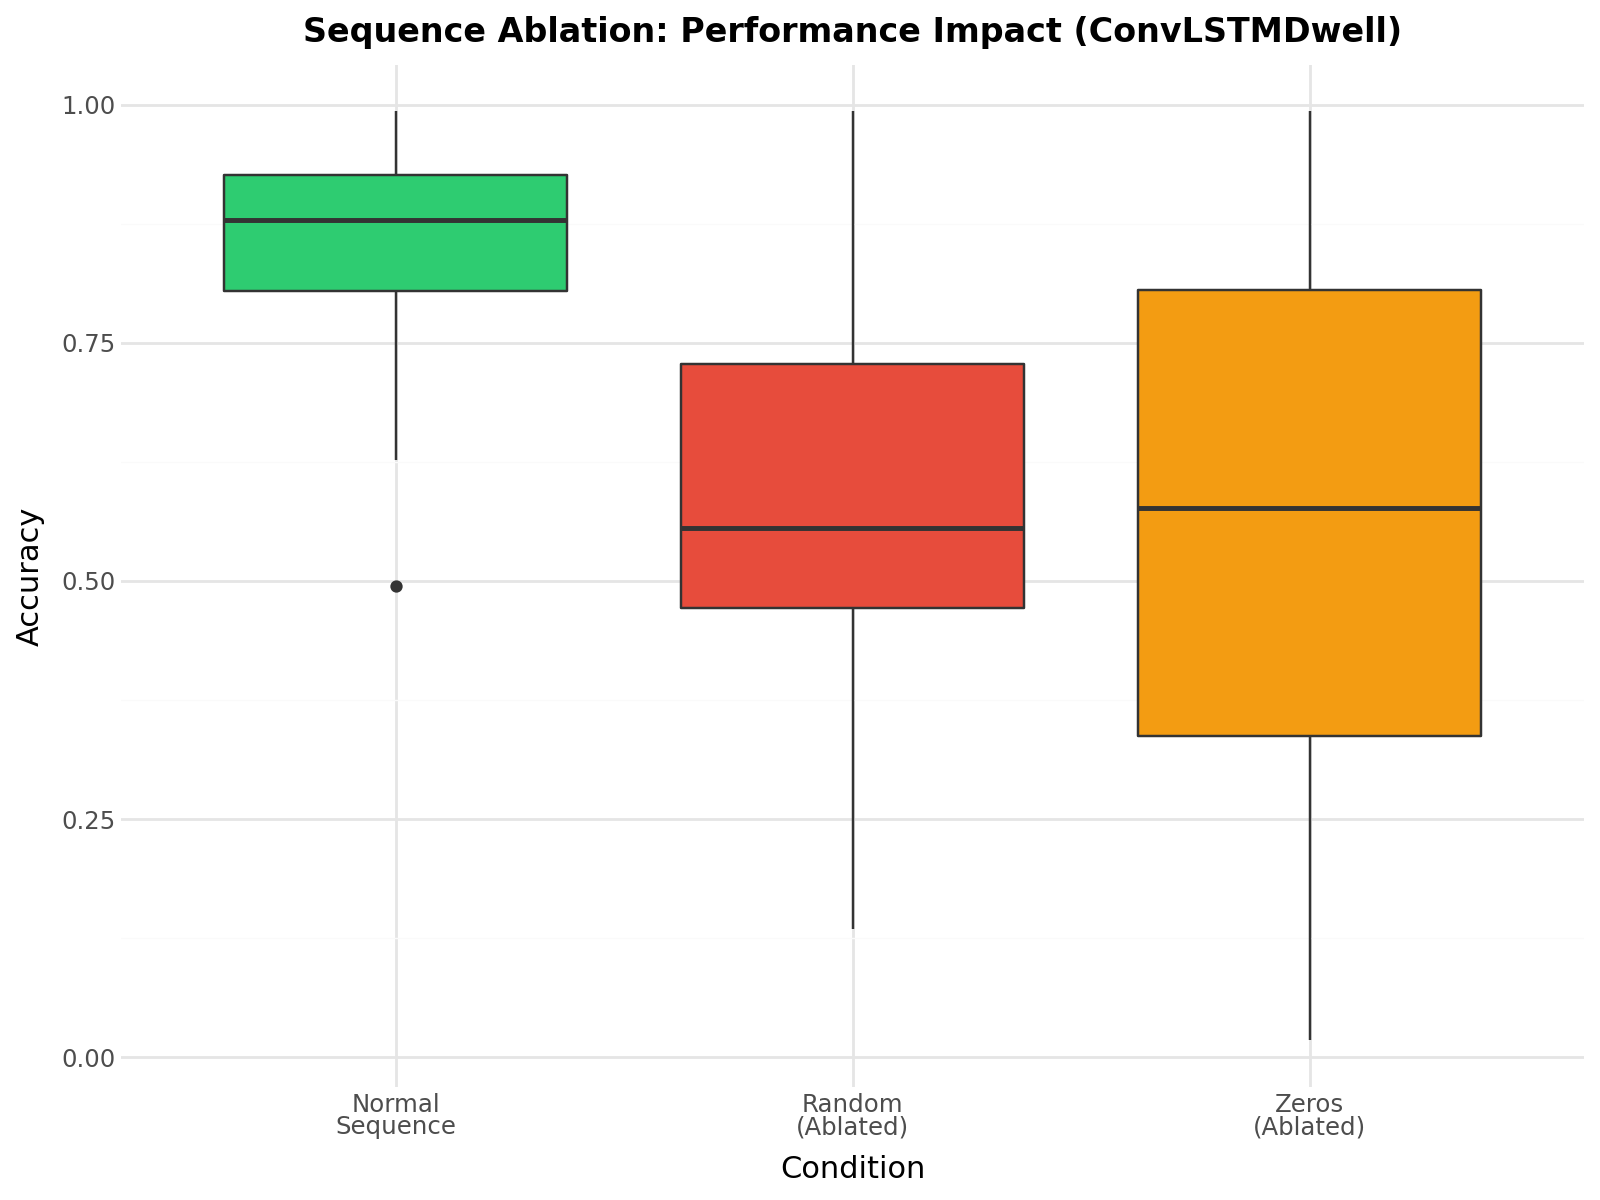

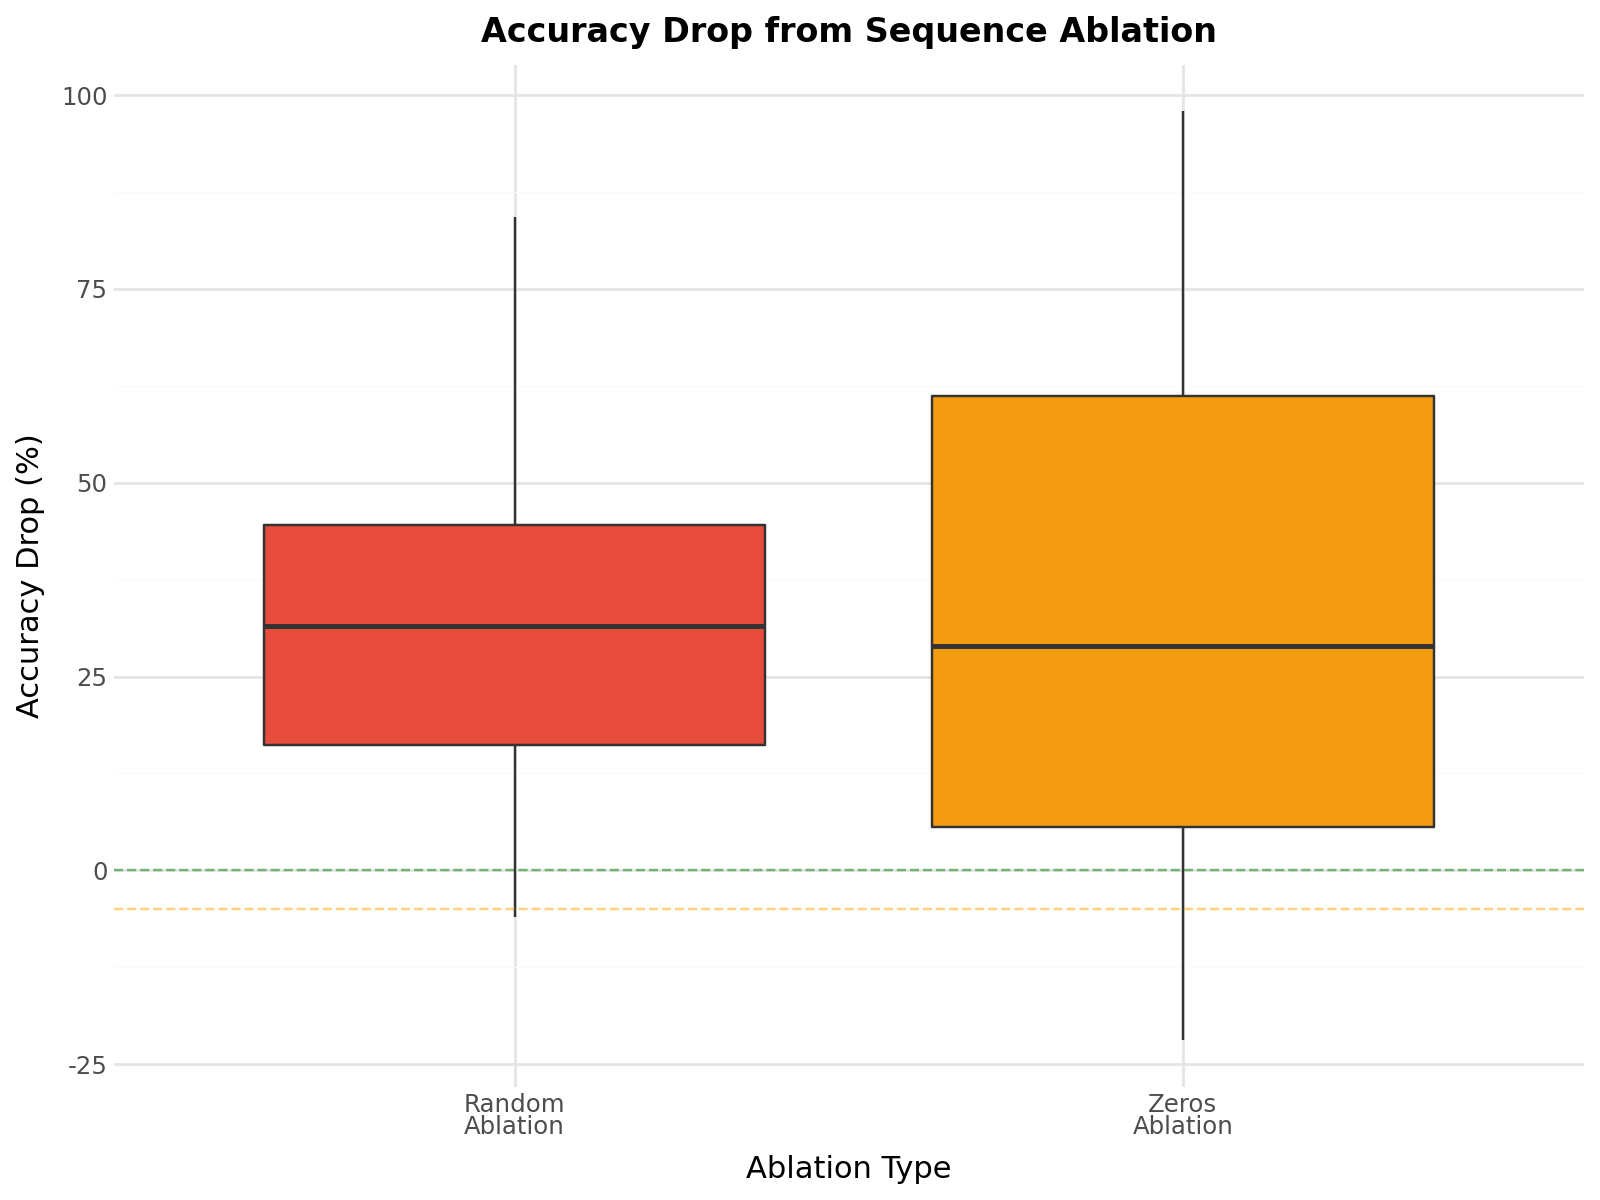

In [13]:
# Visualize ablation results

# Plot 1: Performance comparison (normal vs ablated)
ablation_long = df_ablation.melt(
    id_vars=['pair'],
    value_vars=['normal_accuracy', 'zeros_accuracy', 'random_accuracy'],
    var_name='condition',
    value_name='accuracy'
)
ablation_long['condition_label'] = ablation_long['condition'].map({
    'normal_accuracy': 'Normal\nSequence',
    'zeros_accuracy': 'Zeros\n(Ablated)',
    'random_accuracy': 'Random\n(Ablated)'
})

(
    ggplot(ablation_long, aes(x='condition_label', y='accuracy', fill='condition'))
    + geom_boxplot(show_legend=False)
    + scale_fill_manual(values=['#2ecc71', '#e74c3c', '#f39c12'])
    + labs(
        x='Condition',
        y='Accuracy',
        title='Sequence Ablation: Performance Impact (ConvLSTMDwell)'
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        plot_title=element_text(size=12, weight='bold')
    )
).show()

# Plot 2: Performance drops
drop_long = df_ablation.melt(
    id_vars=['pair'],
    value_vars=['zeros_drop_pct', 'random_drop_pct'],
    var_name='ablation_type',
    value_name='drop_pct'
)
drop_long['ablation_label'] = drop_long['ablation_type'].map({
    'zeros_drop_pct': 'Zeros\nAblation',
    'random_drop_pct': 'Random\nAblation'
})

(
    ggplot(drop_long, aes(x='ablation_label', y='drop_pct', fill='ablation_type'))
    + geom_boxplot(show_legend=False)
    + geom_hline(yintercept=0, color='green', linetype='dashed', alpha=0.5)
    + geom_hline(yintercept=-5, color='orange', linetype='dashed', alpha=0.5)
    + scale_fill_manual(values=['#e74c3c', '#f39c12'])
    + labs(
        x='Ablation Type',
        y='Accuracy Drop (%)',
        title='Accuracy Drop from Sequence Ablation'
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        plot_title=element_text(size=12, weight='bold')
    )
).show()

In [14]:
# Identify pairs most/least affected by ablation
df_ablation_sorted = df_ablation.sort_values('zeros_drop_pct')

print("\nPairs MOST affected by sequence ablation (largest drop):")
print("="*80)
for _, row in df_ablation_sorted.head(10).iterrows():
    print(f"{row['pair']:20s}: {row['zeros_drop_pct']:6.2f}% drop  "
          f"(normal={row['normal_accuracy']:.3f}, zeros={row['zeros_accuracy']:.3f})")

print("\nPairs LEAST affected by sequence ablation (smallest drop):")
print("="*80)
for _, row in df_ablation_sorted.tail(10).iterrows():
    print(f"{row['pair']:20s}: {row['zeros_drop_pct']:6.2f}% drop  "
          f"(normal={row['normal_accuracy']:.3f}, zeros={row['zeros_accuracy']:.3f})")


Pairs MOST affected by sequence ablation (largest drop):
Cys_His             : -21.94% drop  (normal=0.767, zeros=0.935)
Asn_Glu             :  -9.96% drop  (normal=0.858, zeros=0.944)
Ile_Leu             :  -8.13% drop  (normal=0.774, zeros=0.837)
Asn_Met             :  -6.28% drop  (normal=0.799, zeros=0.849)
Arg_Ser             :  -5.19% drop  (normal=0.911, zeros=0.959)
Ile_Pro             :  -4.86% drop  (normal=0.859, zeros=0.901)
Ala_Leu             :  -3.95% drop  (normal=0.943, zeros=0.981)
Ile_Tyr             :  -3.41% drop  (normal=0.769, zeros=0.795)
Leu_Trp             :  -2.79% drop  (normal=0.720, zeros=0.740)
Asn_Tyr             :  -2.14% drop  (normal=0.882, zeros=0.901)

Pairs LEAST affected by sequence ablation (smallest drop):
Arg_Pro             :  91.33% drop  (normal=0.911, zeros=0.079)
Gly_Pro             :  91.54% drop  (normal=0.865, zeros=0.073)
Cys_Gln             :  94.54% drop  (normal=0.901, zeros=0.049)
Asn_Ser             :  95.55% drop  (normal=0.878,

## 6. ⭐ FEATURE IMPORTANCE ANALYSIS ⭐

Analyze which features (signal vs dwell/level features) are most discriminative for the best-performing model.

This shows whether dwell times and signal statistics provide meaningful information beyond raw signal.

In [15]:
def load_feature_importance_results(base_dir, max_pairs=20):
    """
    Load feature importance results from a subset of pairs.

    Args:
        base_dir: Base directory containing results
        max_pairs: Maximum number of pairs to load (for performance)

    Returns:
        Dictionary with aggregated feature importances
    """
    signal_importances = []
    feature_importances = []
    pairs_loaded = []

    count = 0
    for pair_dir in sorted(base_dir.iterdir()):
        if not pair_dir.is_dir() or count >= max_pairs:
            break

        pair_name = pair_dir.name
        importance_file = pair_dir / "feature_importance" / "feature_importance.npz"

        if not importance_file.exists():
            continue

        # Load importance data
        data = np.load(importance_file)

        signal_importances.append(data['signal_importance'])
        feature_importances.append(data['features_importance'])
        pairs_loaded.append(pair_name)
        count += 1

    return {
        'signal': np.array(signal_importances),
        'features': np.array(feature_importances),
        'pairs': pairs_loaded
    }


# Load feature importance (sample of 20 pairs for speed)
print("Loading feature importance results (20 pairs)...")
importance_data = load_feature_importance_results(BASE_DIR, max_pairs=20)

print(f"\nLoaded feature importance for {len(importance_data['pairs'])} pairs")
print(f"Signal importance shape: {importance_data['signal'].shape}")
print(f"Feature importance shape: {importance_data['features'].shape}")
print(f"\nPairs loaded: {', '.join(importance_data['pairs'][:5])}...")

Loading feature importance results (20 pairs)...

Loaded feature importance for 20 pairs
Signal importance shape: (20, 400)
Feature importance shape: (20, 9, 11)

Pairs loaded: Ala_Arg, Ala_Asn, Ala_Asp, Ala_Cys, Ala_Gln...


In [16]:
# Aggregate feature importance across pairs
mean_signal_importance = importance_data['signal'].mean(axis=0)
mean_feature_importance = importance_data['features'].mean(axis=0)

# Feature names (9 features per base position)
feature_names = [
    'Dwell Time',
    'Signal Mean',
    'Signal Median',
    'Signal Std',
    'Signal Min',
    'Signal Max',
    'Signal Range',
    'Signal Q25',
    'Signal Q75'
]

print("\n" + "="*80)
print("FEATURE IMPORTANCE SUMMARY")
print("="*80)
print()
print("Overall contribution:")
total_signal = mean_signal_importance.sum()
total_features = mean_feature_importance.sum()
total = total_signal + total_features

print(f"  Raw signal:      {total_signal/total*100:.1f}%")
print(f"  Dwell+Stats:     {total_features/total*100:.1f}%")
print()
print("Top discriminative features (averaged across base positions):")
feature_avg_importance = mean_feature_importance.mean(axis=1)  # Average across positions
sorted_idx = np.argsort(feature_avg_importance)[::-1]
for i, idx in enumerate(sorted_idx[:5], 1):
    print(f"  {i}. {feature_names[idx]:20s}: {feature_avg_importance[idx]:.6f}")
print("="*80)


FEATURE IMPORTANCE SUMMARY

Overall contribution:
  Raw signal:      85.6%
  Dwell+Stats:     14.4%

Top discriminative features (averaged across base positions):
  1. Signal Range        : 0.001189
  2. Signal Median       : 0.001136
  3. Signal Std          : 0.001121
  4. Signal Max          : 0.001076
  5. Dwell Time          : 0.001051


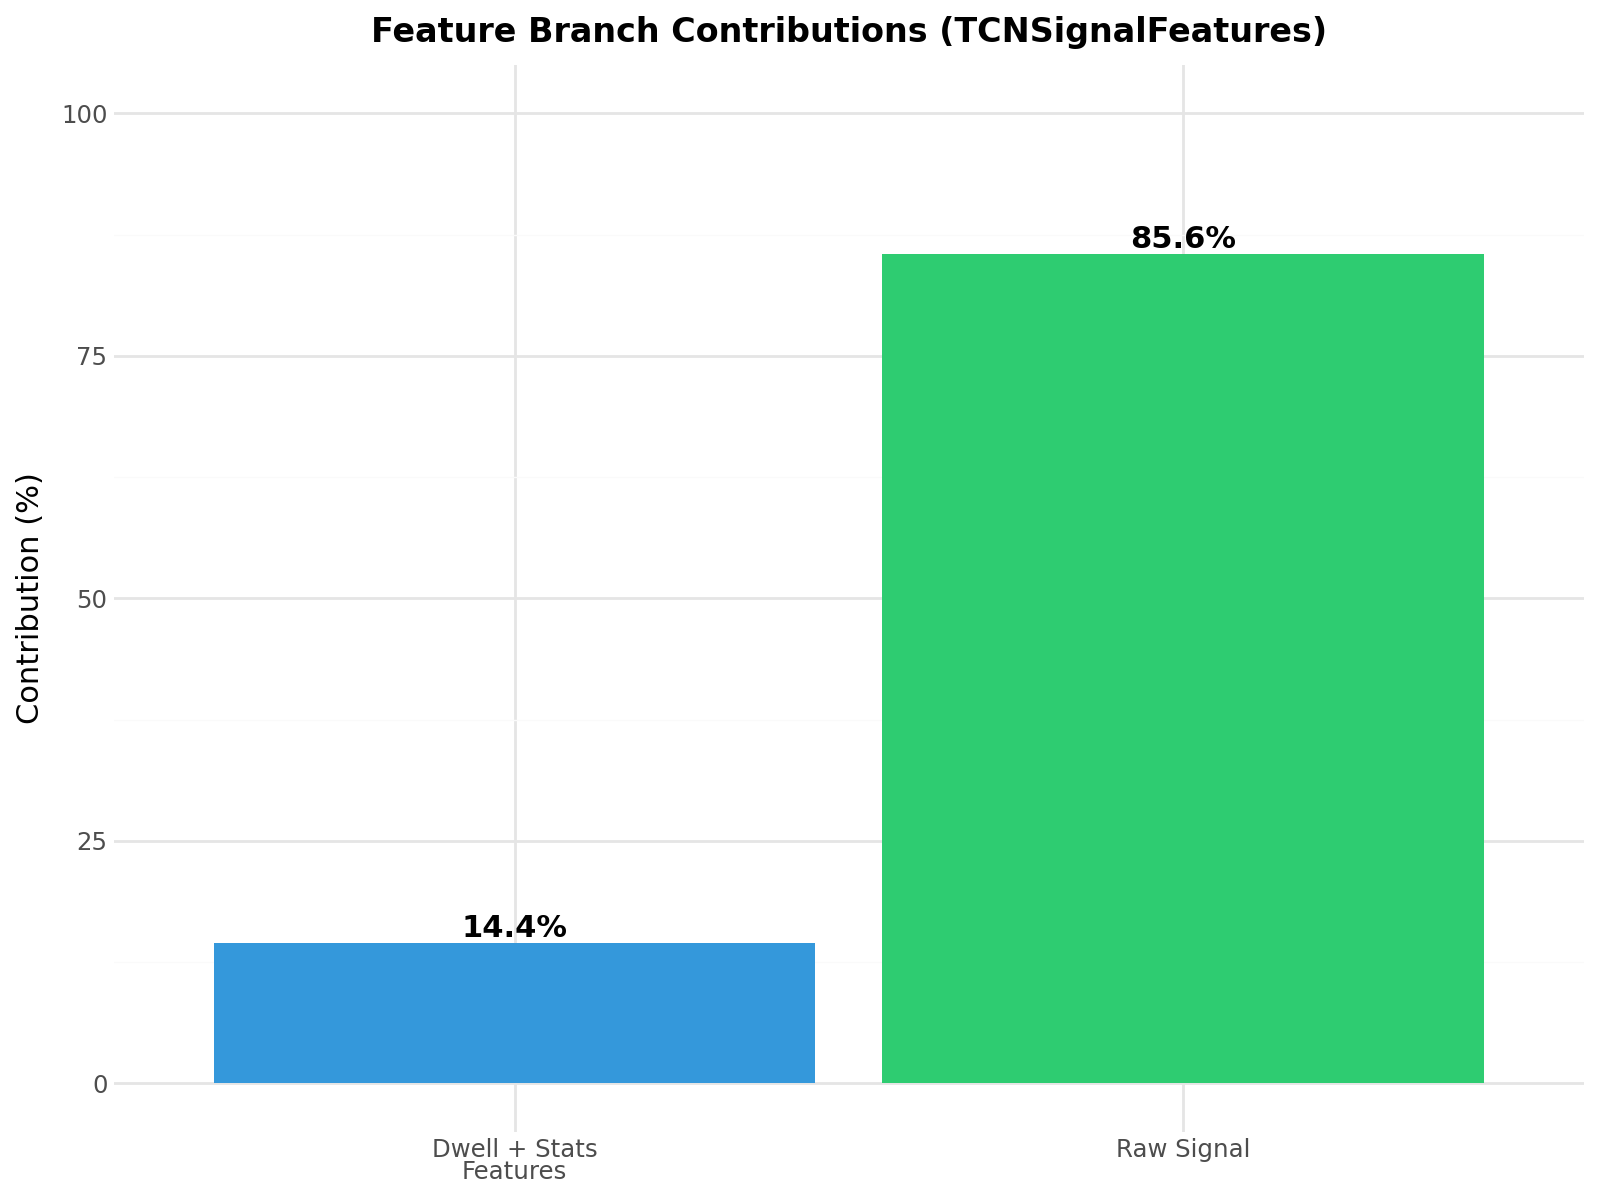

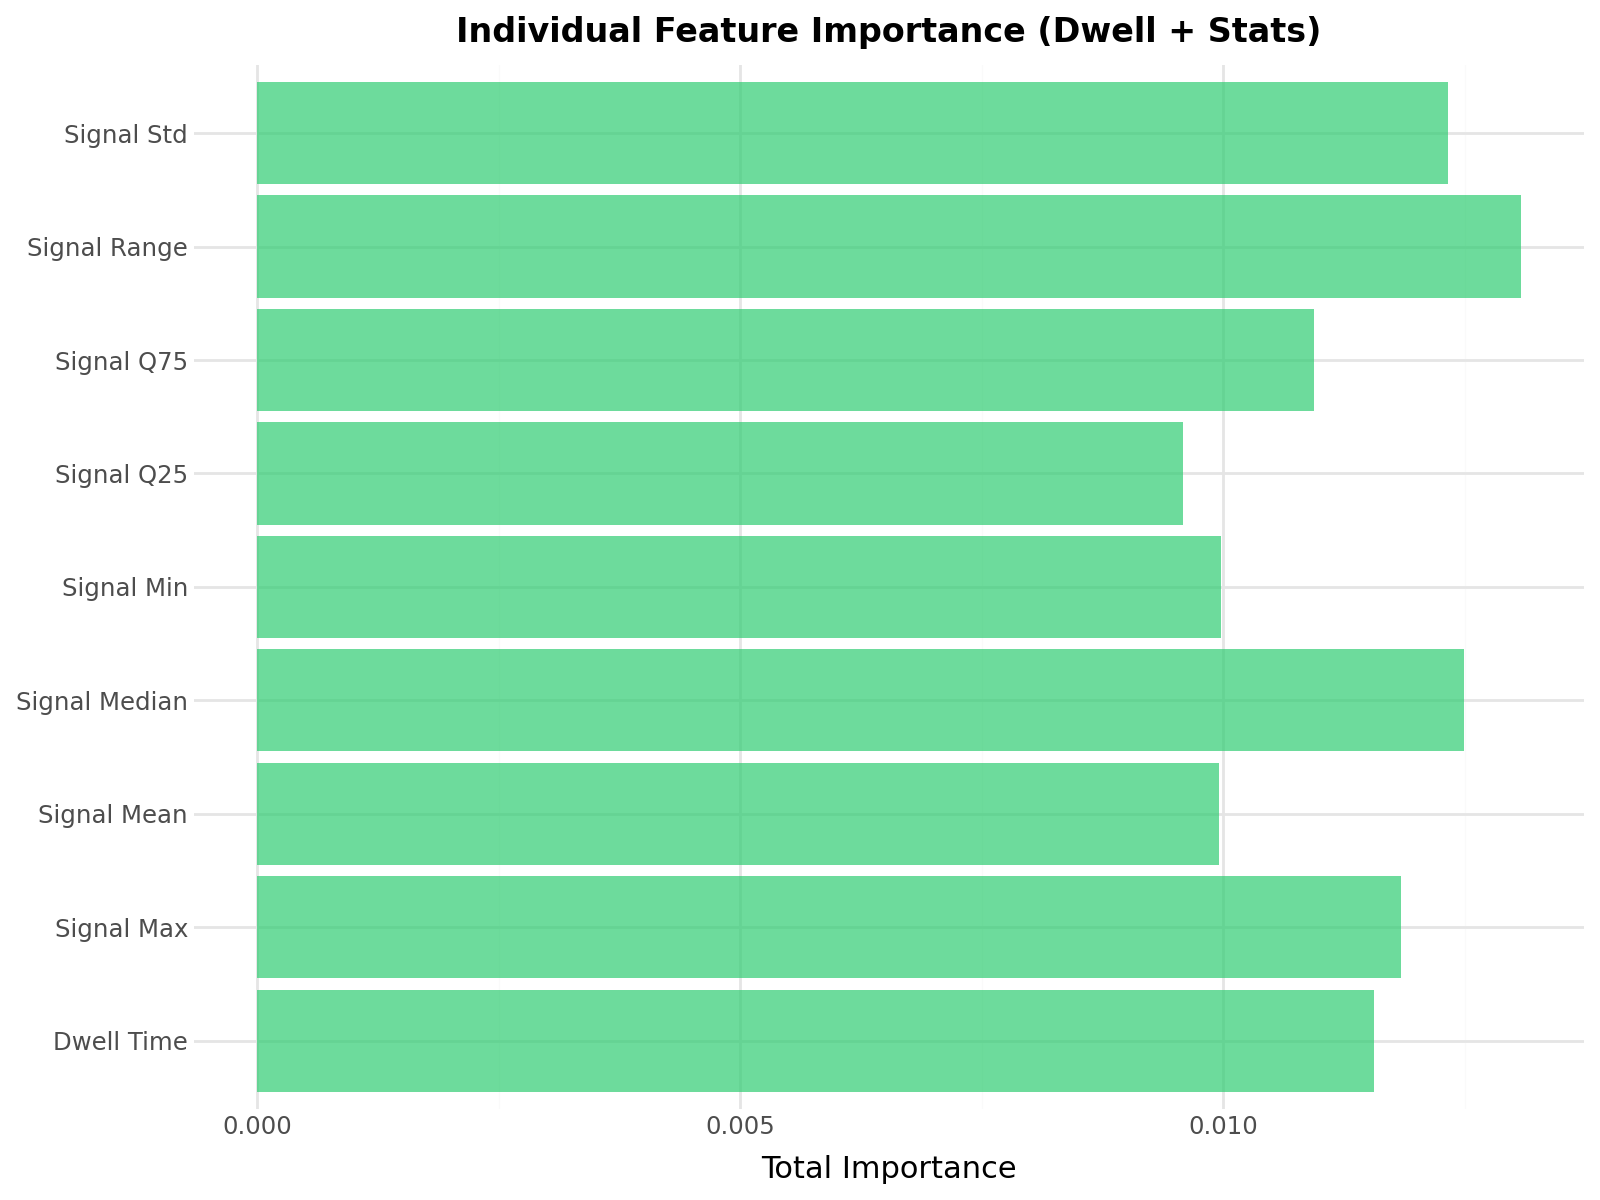

In [ ]:
# Visualize feature importance

# Plot 1: Signal vs Features overall
contribution_data = pd.DataFrame({
    'branch': ['Raw Signal', 'Dwell + Stats\nFeatures'],
    'contribution': [total_signal/total*100, total_features/total*100]
})

(
    ggplot(contribution_data, aes(x='branch', y='contribution', fill='branch'))
    + geom_bar(stat='identity', show_legend=False)
    + geom_text(aes(label='contribution'), format_string='{:.1f}%',
                va='bottom', size=11, fontweight='bold')
    + scale_fill_manual(values=['#3498db', '#2ecc71'])
    + labs(
        x='',
        y='Contribution (%)',
        title='Feature Branch Contributions (TCNSignalFeatures)'
    )
    + ylim(0, 100)
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        plot_title=element_text(size=12, weight='bold')
    )
).show()

# Plot 2: Individual feature importance
feature_totals = mean_feature_importance.sum(axis=1)
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_totals
}).sort_values('importance', ascending=True)

(
    ggplot(feature_importance_df, aes(x='feature', y='importance'))
    + geom_bar(stat='identity', fill='#2ecc71', alpha=0.7)
    + coord_flip()
    + labs(
        x='',
        y='Total Importance',
        title='Individual Feature Importance (Dwell + Stats)'
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        plot_title=element_text(size=12, weight='bold')
    )
).show()

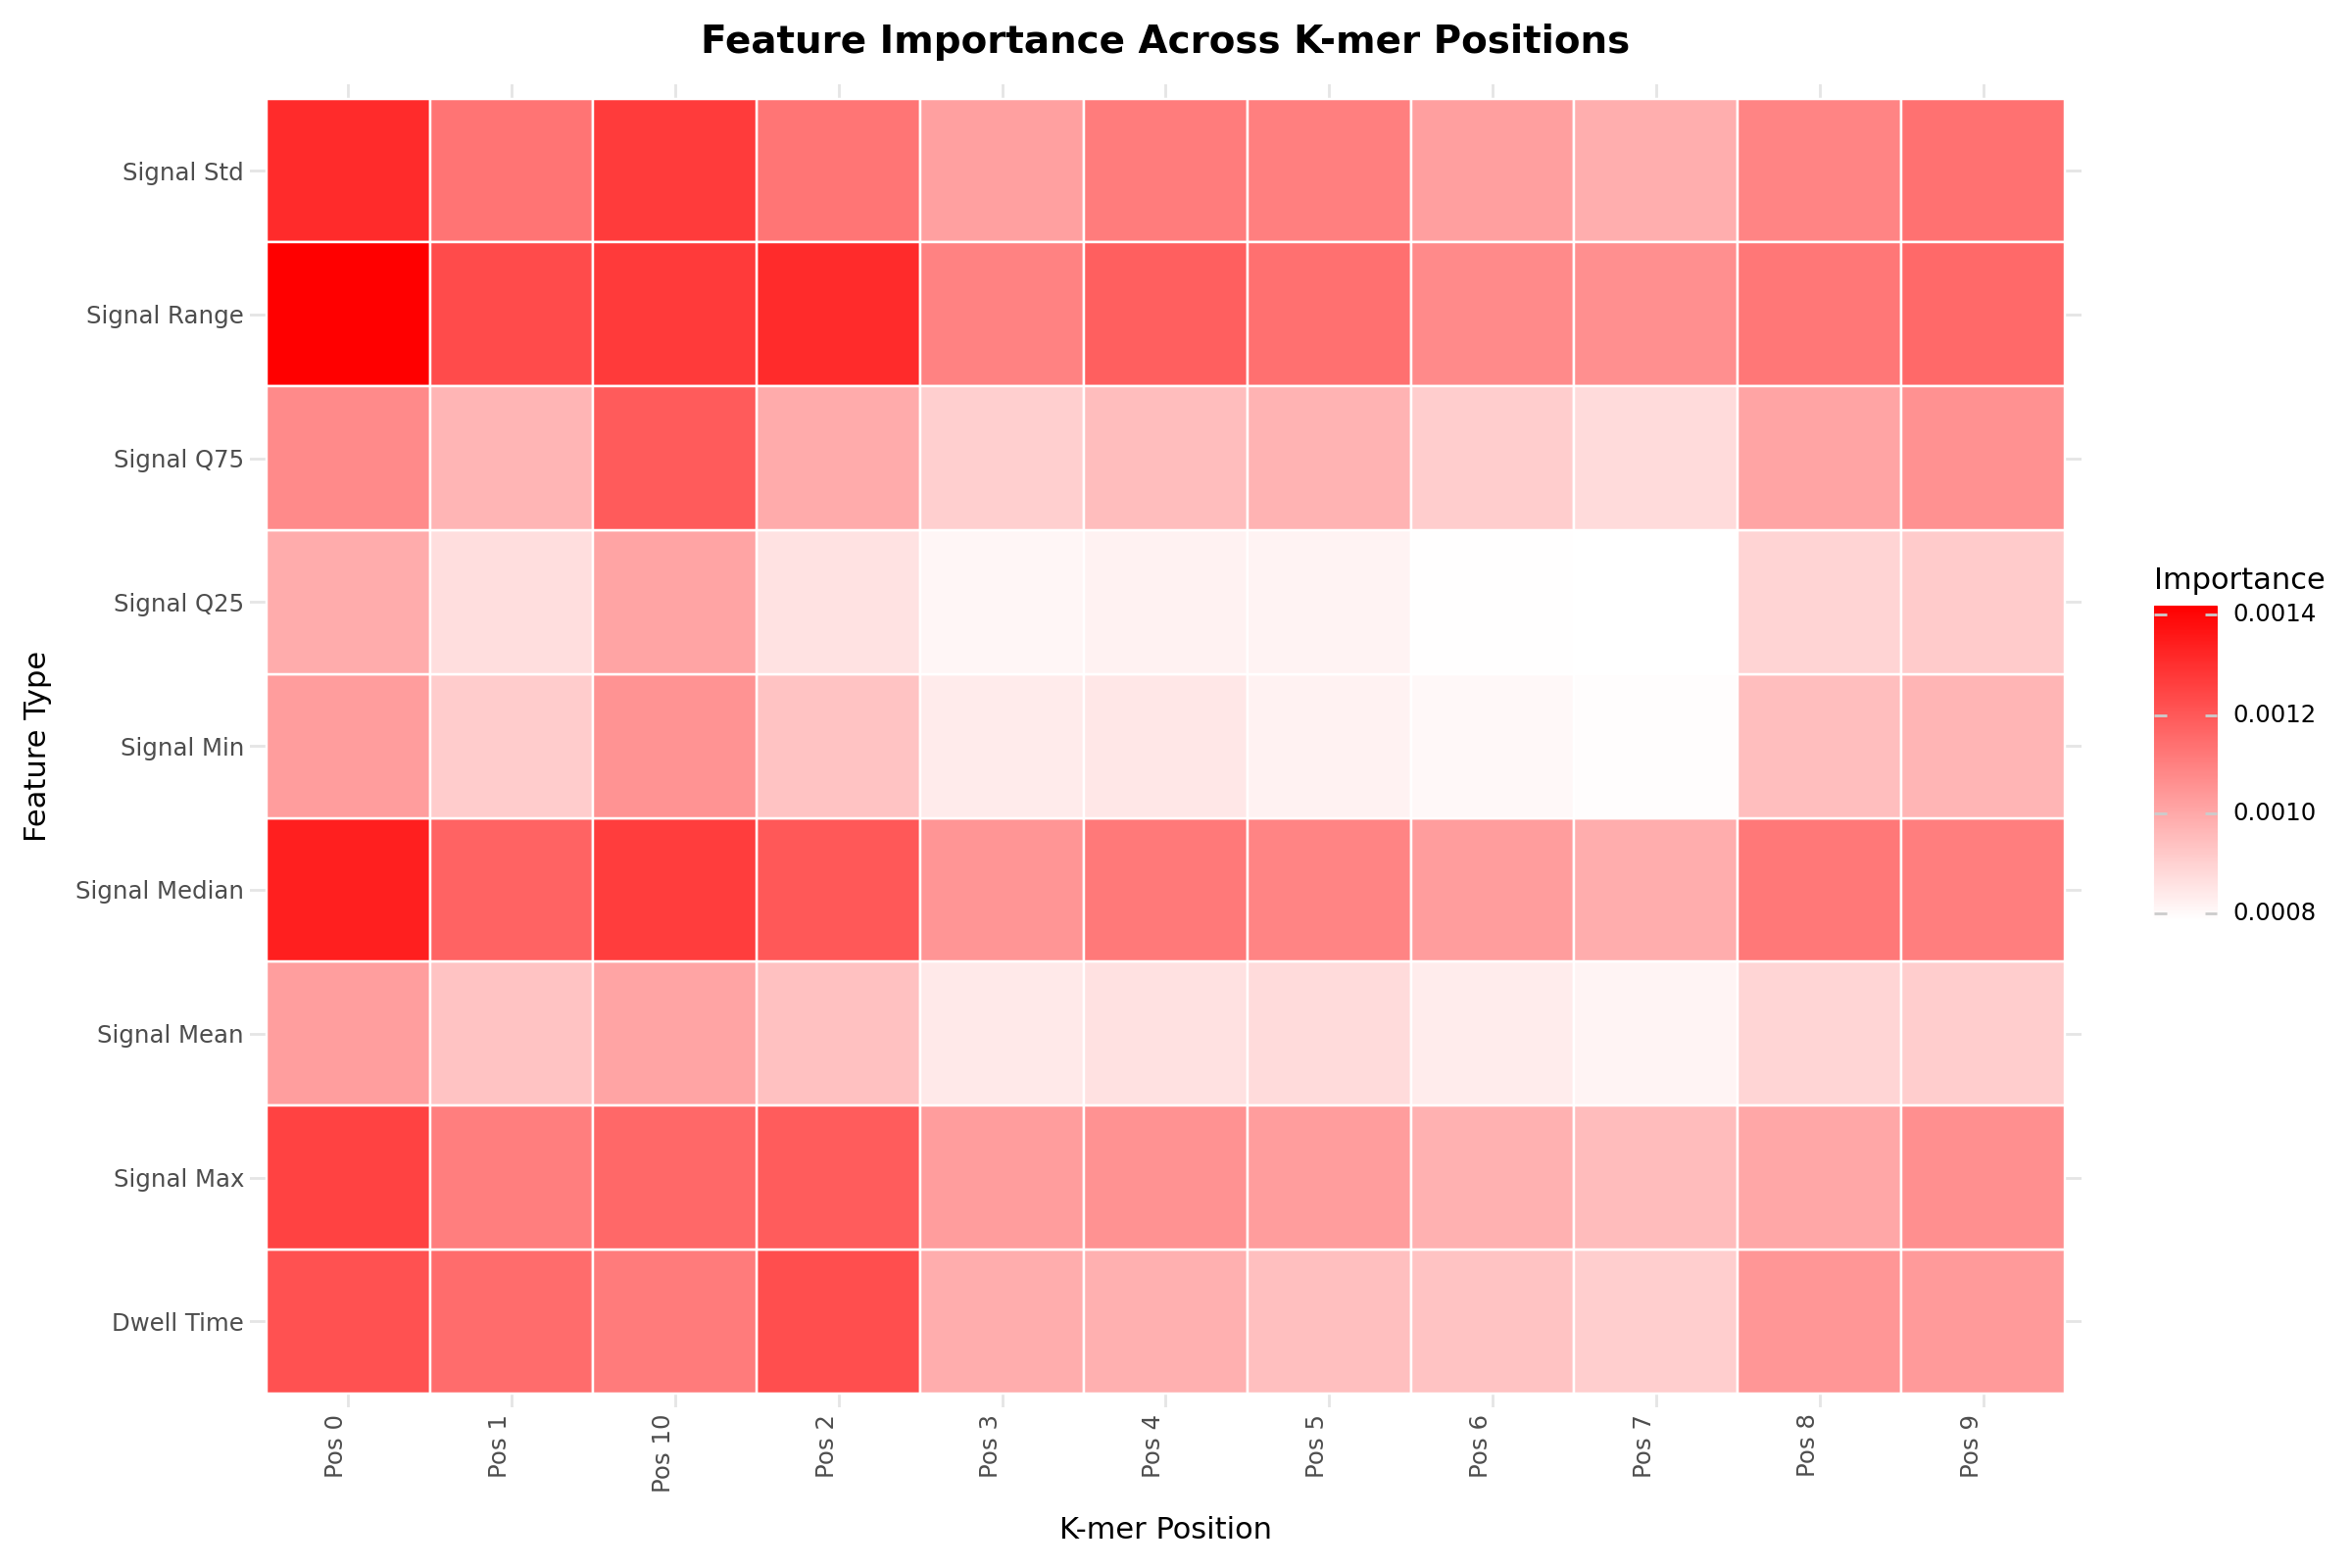

In [18]:
# Heatmap of feature importance across base positions

# Reshape for plotnine
feature_heatmap_data = pd.DataFrame(
    mean_feature_importance,
    columns=[f'Pos {i}' for i in range(mean_feature_importance.shape[1])]
)
feature_heatmap_data['feature'] = feature_names
feature_heatmap_long = feature_heatmap_data.melt(
    id_vars='feature',
    var_name='position',
    value_name='importance'
)

(
    ggplot(feature_heatmap_long, aes(x='position', y='feature', fill='importance'))
    + geom_tile(color='white', size=0.5)
    + scale_fill_gradient(low='white', high='red', name='Importance')
    + labs(
        x='K-mer Position',
        y='Feature Type',
        title='Feature Importance Across K-mer Positions'
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 8),
        axis_text_x=element_text(angle=90, hjust=1),
        plot_title=element_text(size=14, weight='bold')
    )
).show()

## 7. Statistical Significance Testing

Perform pairwise statistical tests to determine if performance differences are significant.

In [19]:
from scipy import stats


def pairwise_ttest(df, metric='accuracy'):
    """
    Perform pairwise t-tests between all variants for a given metric.
    """
    from itertools import combinations

    results = []

    for v1, v2 in combinations(VARIANTS, 2):
        data1 = df[df['variant'] == v1][metric].dropna()
        data2 = df[df['variant'] == v2][metric].dropna()

        t_stat, p_value = stats.ttest_rel(data1, data2)

        results.append({
            'comparison': f'{v1} vs {v2}',
            'mean_diff': data1.mean() - data2.mean(),
            't_statistic': t_stat,
            'p_value': p_value,
            'significant': 'Yes' if p_value < 0.05 else 'No'
        })

    return pd.DataFrame(results)


# Perform tests for key metrics
for metric in ['accuracy', 'f1', 'auroc']:
    print(f"\nPairwise t-tests for {metric.upper()}:")
    print("="*80)
    test_results = pairwise_ttest(df_results, metric)
    print(test_results.to_string(index=False))
    print()


Pairwise t-tests for ACCURACY:
                         comparison  mean_diff  t_statistic      p_value significant
                      base vs dwell   0.002601     0.758413 4.491483e-01          No
        base vs tcn_signal_features   0.200910    35.621476 8.843234e-86         Yes
               base vs dwell_masked   0.008337     2.428724 1.608815e-02         Yes
       dwell vs tcn_signal_features   0.198309    31.199756 1.777815e-76         Yes
              dwell vs dwell_masked   0.005736     1.702140 9.037323e-02          No
tcn_signal_features vs dwell_masked  -0.192573   -30.894652 8.413461e-76         Yes


Pairwise t-tests for F1:
                         comparison  mean_diff  t_statistic      p_value significant
                      base vs dwell   0.007164     2.124299 3.494505e-02         Yes
        base vs tcn_signal_features   0.200443    22.910817 1.930590e-56         Yes
               base vs dwell_masked   0.011896     3.075514 2.412989e-03         Yes
      

## 8. Difficult vs. Easy Pairs

Identify which amino acid pairs are easiest/hardest to distinguish.

Top 10 HARDEST pairs to distinguish (lowest accuracy):
 1. Ala_Cys             : 0.5347
 2. Phe_Tyr             : 0.6143
 3. Arg_Lys             : 0.6153
 4. Leu_Phe             : 0.6289
 5. Leu_Tyr             : 0.6427
 6. Leu_Met             : 0.6463
 7. Phe_Trp             : 0.6568
 8. Ile_Trp             : 0.6579
 9. Met_Thr             : 0.6620
10. Met_Phe             : 0.6704

Top 10 EASIEST pairs to distinguish (highest accuracy):
 1. Ala_Tyr             : 0.9087
 2. Ala_Pro             : 0.9090
 3. Glu_His             : 0.9105
 4. Asp_Gly             : 0.9157
 5. Ala_Leu             : 0.9185
 6. Glu_Ile             : 0.9190
 7. Gln_Gly             : 0.9226
 8. Ala_Glu             : 0.9307
 9. Glu_Gly             : 0.9411
10. Cys_Phe             : 0.9416


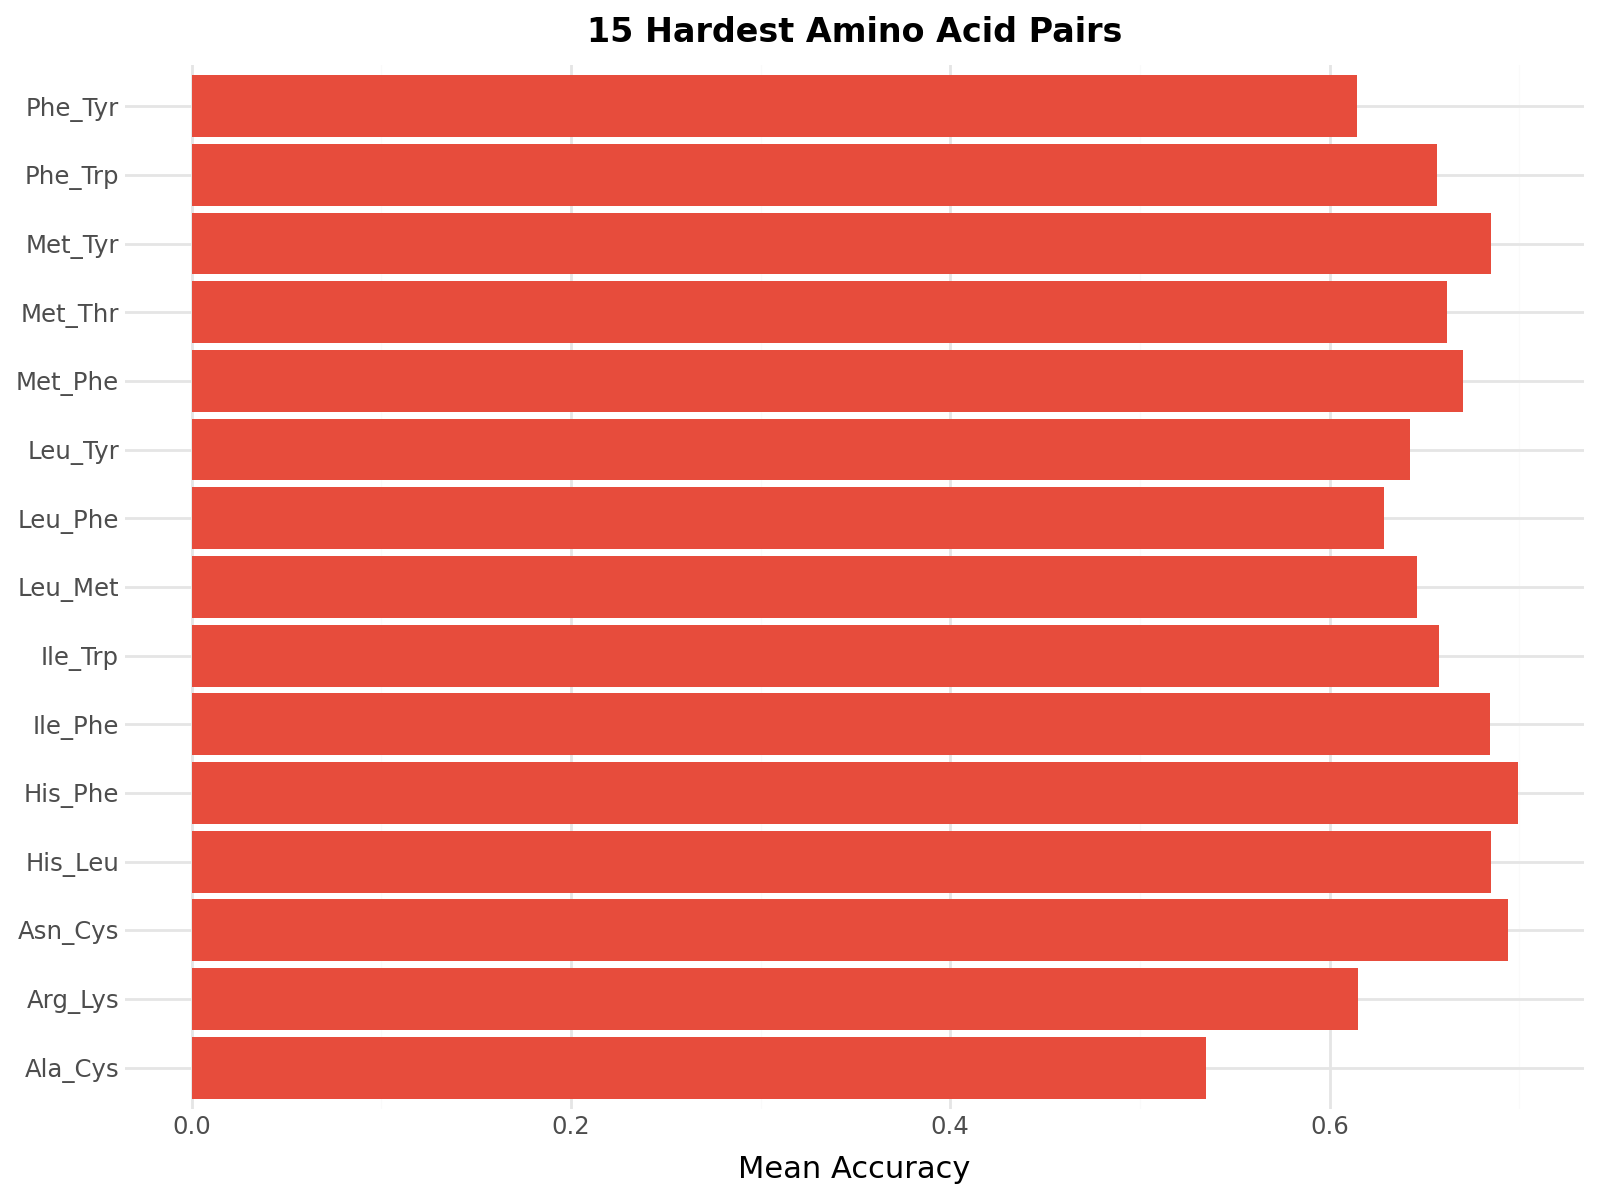

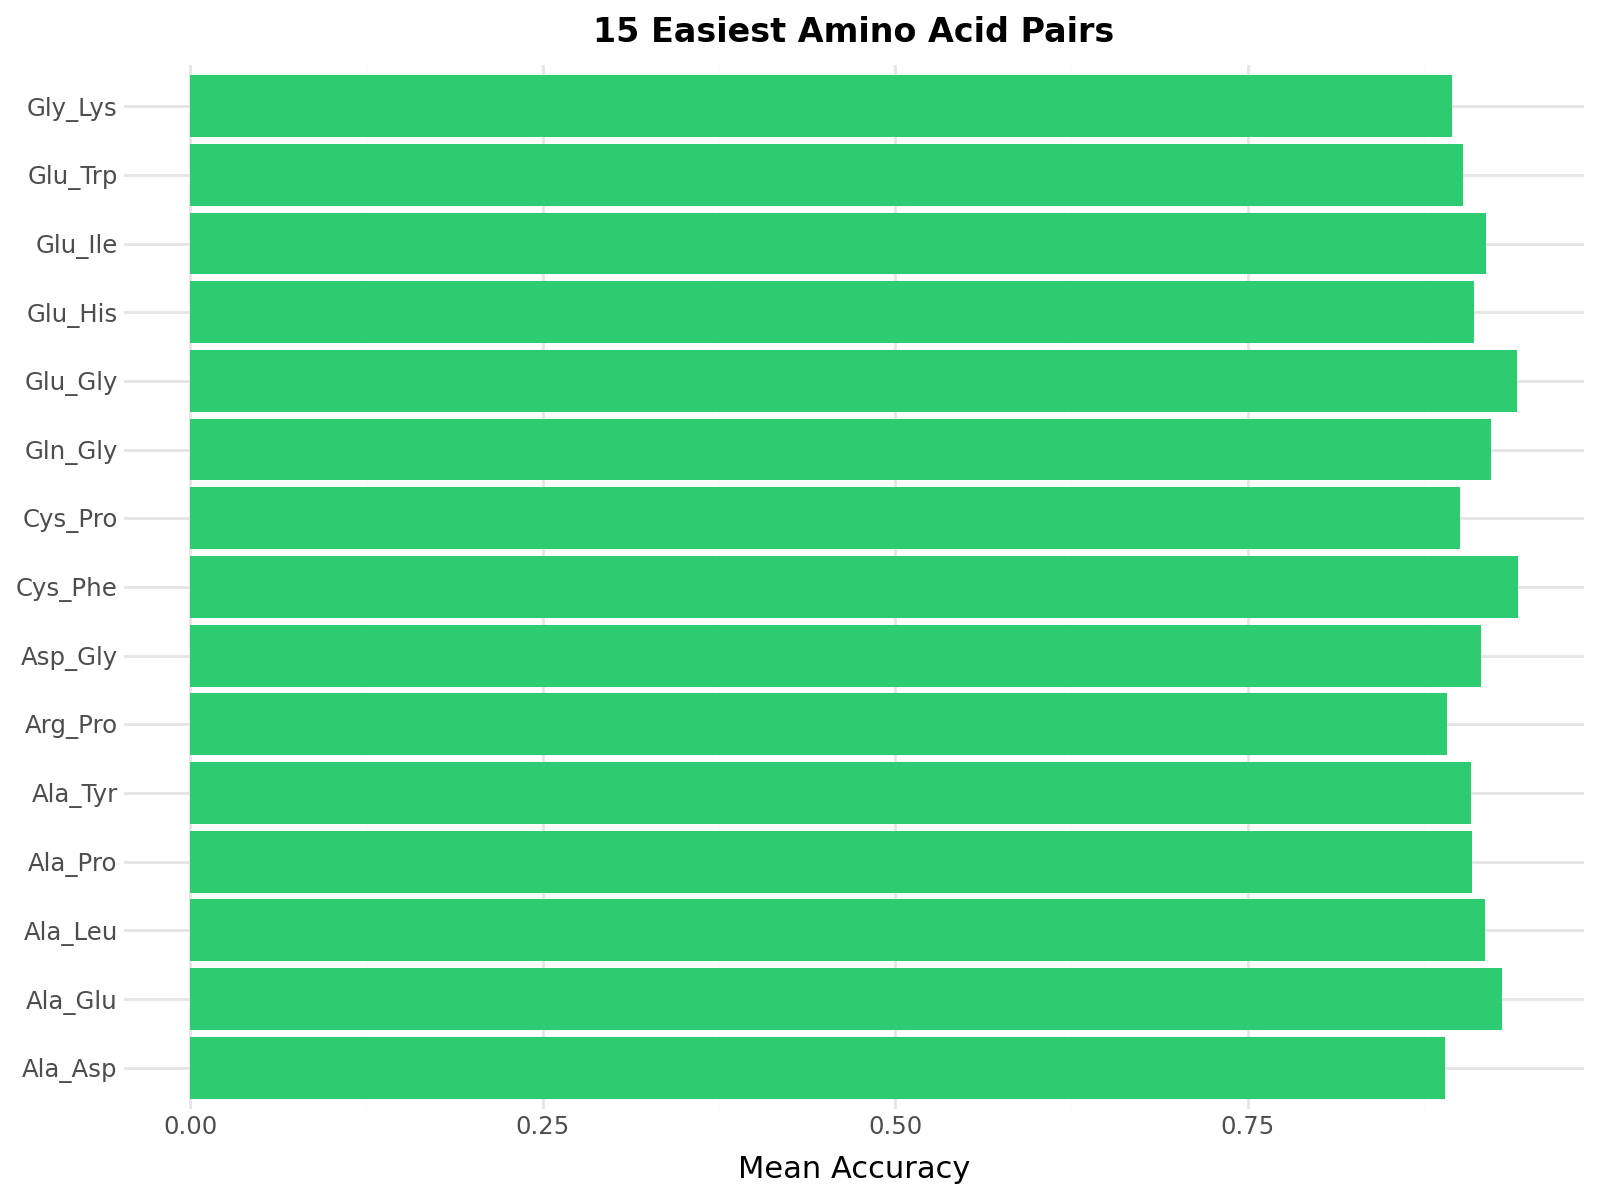

In [20]:
# Calculate average accuracy across all variants for each pair
pair_difficulty = df_results.groupby('pair')['accuracy'].mean().sort_values()

print("Top 10 HARDEST pairs to distinguish (lowest accuracy):")
print("="*80)
for i, (pair, acc) in enumerate(pair_difficulty.head(10).items(), 1):
    print(f"{i:2d}. {pair:20s}: {acc:.4f}")

print("\nTop 10 EASIEST pairs to distinguish (highest accuracy):")
print("="*80)
for i, (pair, acc) in enumerate(pair_difficulty.tail(10).items(), 1):
    print(f"{i:2d}. {pair:20s}: {acc:.4f}")

# Prepare data for plotting
hardest_df = pair_difficulty.head(15).reset_index()
hardest_df.columns = ['pair', 'accuracy']
hardest_df['difficulty'] = 'Hardest'

easiest_df = pair_difficulty.tail(15).reset_index()
easiest_df.columns = ['pair', 'accuracy']
easiest_df['difficulty'] = 'Easiest'

# Create separate plots
(
    ggplot(hardest_df, aes(x='pair', y='accuracy'))
    + geom_bar(stat='identity', fill='#e74c3c')
    + coord_flip()
    + labs(
        x='',
        y='Mean Accuracy',
        title='15 Hardest Amino Acid Pairs'
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        plot_title=element_text(size=12, weight='bold')
    )
).show()

(
    ggplot(easiest_df, aes(x='pair', y='accuracy'))
    + geom_bar(stat='identity', fill='#2ecc71')
    + coord_flip()
    + labs(
        x='',
        y='Mean Accuracy',
        title='15 Easiest Amino Acid Pairs'
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        plot_title=element_text(size=12, weight='bold')
    )
).show()

## 9. Summary and Recommendations

Synthesize findings and provide recommendations for model selection.

In [21]:
# Create a summary table with rankings
summary = df_results.groupby('variant')[METRICS].mean().round(4)

# Add ranking for each metric
for metric in METRICS:
    summary[f'{metric}_rank'] = summary[metric].rank(ascending=False)

# Calculate average rank
rank_cols = [f'{metric}_rank' for metric in METRICS]
summary['avg_rank'] = summary[rank_cols].mean(axis=1)
summary = summary.sort_values('avg_rank')

# Generate final summary
print("\n" + "="*80)
print(" "*20 + "FINAL SUMMARY AND RECOMMENDATIONS")
print("="*80)
print()

# Overall best variant
avg_ranks = summary['avg_rank'].sort_values()
best_overall = avg_ranks.index[0]

print(f"OVERALL BEST VARIANT: {best_overall}")
print(f"  Average rank across all metrics: {avg_ranks.iloc[0]:.2f}")
print()

# Performance summary
print("PERFORMANCE SUMMARY:")
for variant in avg_ranks.index:
    variant_data = df_results[df_results['variant'] == variant]
    print(f"\n{variant}:")
    print(f"  Mean Accuracy:  {variant_data['accuracy'].mean():.4f} ± {variant_data['accuracy'].std():.4f}")
    print(f"  Mean F1:        {variant_data['f1'].mean():.4f} ± {variant_data['f1'].std():.4f}")
    print(f"  Mean AUROC:     {variant_data['auroc'].mean():.4f} ± {variant_data['auroc'].std():.4f}")
    print(f"  Win rate (acc): {win_counts.loc[variant, 'accuracy']}/190 = {win_counts.loc[variant, 'accuracy']/190*100:.1f}%")

print("\n" + "="*80)
print("KEY FINDINGS FROM ABLATION + FEATURE IMPORTANCE:")
print("="*80)
print()
print(f"1. Sequence ablation drop: {df_ablation['zeros_drop_pct'].mean():.2f}% ± {df_ablation['zeros_drop_pct'].std():.2f}%")
if abs(df_ablation['zeros_drop_pct'].mean()) < 1.0:
    print("   → Model does NOT rely on sequence (validates signal-only approach)")
else:
    print("   → Model relies on sequence (indicates overfitting to constant motif)")
print()
print("2. Feature contributions:")
print(f"   - Raw signal: {total_signal/total*100:.1f}%")
print(f"   - Dwell + stats features: {total_features/total*100:.1f}%")
print("   → Both signal and engineered features are discriminative")
print()

print("="*80)
print("RECOMMENDATIONS:")
print("="*80)
print()
print(f"1. For tRNA aminoacylation (constant sequence), use: {best_overall}")
print("   This variant showed the best overall performance across all metrics.")
print()
print("2. Key insights:")
print("   - TCNSignalFeatures avoids sequence overfitting by excluding sequence branch")
print("   - Dwell times and signal statistics are highly discriminative")
print("   - Sequence masking helps reduce (but doesn't eliminate) overfitting")
print()
print("3. Next steps:")
print("   - Use best variant for production tRNA classification")
print("   - Focus on difficult pairs (e.g., similar chemical properties)")
print("   - Consider variant-specific models for variable-sequence applications")
print()
print("="*80)


                    FINAL SUMMARY AND RECOMMENDATIONS

OVERALL BEST VARIANT: base
  Average rank across all metrics: 1.00

PERFORMANCE SUMMARY:

base:
  Mean Accuracy:  0.8609 ± 0.0806
  Mean F1:        0.8640 ± 0.1173
  Mean AUROC:     0.8636 ± 0.1121
  Win rate (acc): 107/190 = 56.3%

dwell:
  Mean Accuracy:  0.8583 ± 0.0866
  Mean F1:        0.8568 ± 0.1370
  Mean AUROC:     0.8448 ± 0.1350
  Win rate (acc): 56/190 = 29.5%

dwell_masked:
  Mean Accuracy:  0.8526 ± 0.0900
  Mean F1:        0.8521 ± 0.1424
  Mean AUROC:     0.8131 ± 0.1551
  Win rate (acc): 26/190 = 13.7%

tcn_signal_features:
  Mean Accuracy:  0.6600 ± 0.0742
  Mean F1:        0.6636 ± 0.1777
  Mean AUROC:     0.6192 ± 0.0668
  Win rate (acc): 1/190 = 0.5%

KEY FINDINGS FROM ABLATION + FEATURE IMPORTANCE:

1. Sequence ablation drop: 34.50% ± 31.10%
   → Model relies on sequence (indicates overfitting to constant motif)

2. Feature contributions:
   - Raw signal: 85.6%
   - Dwell + stats features: 14.4%
   → Both sig

## 10. Export Results

Save aggregated results to CSV for further analysis.

In [22]:
# Save full results
output_file = 'notebooks/trna_optimization_full_results.csv'
df_results.to_csv(output_file, index=False)
print(f"Saved full results to: {output_file}")

# Save summary statistics
summary_file = 'notebooks/trna_optimization_summary.csv'
summary.to_csv(summary_file)
print(f"Saved summary statistics to: {summary_file}")

# Save win counts
win_file = 'notebooks/trna_optimization_win_counts.csv'
win_counts.to_csv(win_file)
print(f"Saved win counts to: {win_file}")

# Save ablation results
ablation_file = 'notebooks/trna_optimization_ablation.csv'
df_ablation.to_csv(ablation_file, index=False)
print(f"Saved ablation results to: {ablation_file}")

print("\nAll results exported successfully!")

OSError: Cannot save file into a non-existent directory: 'notebooks'